# Week-33

In [2]:
from pathlib import Path
import re

import pandas as pd
from IPython.display import display


# =========================================================
# Paths
# =========================================================

REPO_ROOT = Path("/Users/acw792/Developer/qmul-phd-framework")

RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_sweep_train_ratios_"
        "10-90_pseudo_properties_Apocrita_neg_const"
    )
)

LOG_DIR = RESULT_ROOT / "terminal_logs"

if not RESULT_ROOT.is_dir():
    raise FileNotFoundError(f"RESULT_ROOT does not exist:\n{RESULT_ROOT}")

if not LOG_DIR.is_dir():
    raise FileNotFoundError(f"Terminal-log directory does not exist:\n{LOG_DIR}")


# =========================================================
# Extract negative-pool information
# =========================================================

NEGPOOL_PATTERN = re.compile(
    r"role_pool=(?P<role_pool>\d+).*?"
    r"full_pool=(?P<full_pool>\d+).*?"
    r"need_total=(?P<need_total>\d+).*?"
    r"constrained_neg=(?P<ecological_selected>\d+)\s+"
    r"random_topup=(?P<random_topup>\d+)"
)

log_paths = sorted(LOG_DIR.glob("*_terminal_log.txt"))

if not log_paths:
    raise FileNotFoundError(
        f"No terminal logs were found in:\n{LOG_DIR}"
    )

rows = []

for log_path in log_paths:
    log_text = log_path.read_text(errors="replace")

    matches = [
        tuple(map(int, match.groups()))
        for match in NEGPOOL_PATTERN.finditer(log_text)
    ]

    if not matches:
        raise ValueError(
            f"No compatible [NegPool] entries were found in:\n"
            f"{log_path.name}"
        )

    # Each food-web log contains repeated executions corresponding
    # to the iterations and training ratios. Pool sizes and required
    # counts should remain identical across those executions.
    unique_matches = set(matches)

    if len(unique_matches) != 1:
        raise ValueError(
            f"{log_path.name} contains {len(unique_matches)} different "
            "negative-pool configurations."
        )

    (
        role_pool,
        full_pool,
        need_total,
        ecological_selected,
        random_topup,
    ) = unique_matches.pop()

    food_web = log_path.name.replace(
        "_tax_mass_wlnm_dir_neg_terminal_log.txt",
        "",
    )

    rows.append(
        {
            "FoodWeb": food_web,
            "EcologicalCandidatePool": role_pool,
            "OutsideEcologicalRules": full_pool - role_pool,
            "FullCandidatePool": full_pool,
            "RequiredNegatives": need_total,
            "EcologicalSelected": ecological_selected,
            "RandomTopUp": random_topup,
            "LogOccurrences": len(matches),
        }
    )

foodweb_pool_df = pd.DataFrame(rows)


# =========================================================
# Validate extracted data
# =========================================================

expected_food_webs = 290

assert len(foodweb_pool_df) == expected_food_webs, (
    f"Expected {expected_food_webs} food webs, "
    f"but found {len(foodweb_pool_df)}."
)

assert (
    foodweb_pool_df["EcologicalCandidatePool"]
    <= foodweb_pool_df["FullCandidatePool"]
).all(), "An ecological pool is larger than its full candidate pool."

assert (
    foodweb_pool_df["EcologicalSelected"]
    + foodweb_pool_df["RandomTopUp"]
    == foodweb_pool_df["RequiredNegatives"]
).all(), (
    "For at least one food web, ecological negatives plus random "
    "top-up do not equal the required number of negatives."
)


# =========================================================
# 1. Potential candidate space
# =========================================================

total_candidate_pool = int(
    foodweb_pool_df["FullCandidatePool"].sum()
)

ecological_candidates = int(
    foodweb_pool_df["EcologicalCandidatePool"].sum()
)

outside_rules_candidates = int(
    foodweb_pool_df["OutsideEcologicalRules"].sum()
)

candidate_summary = pd.DataFrame(
    {
        "Candidate type": [
            "Under ecological sampling rules",
            "Outside ecological sampling rules",
        ],
        "Links": [
            ecological_candidates,
            outside_rules_candidates,
        ],
    }
)

candidate_summary["Percentage"] = (
    100
    * candidate_summary["Links"]
    / total_candidate_pool
).round(2)


# =========================================================
# 2. Negative links actually selected
# =========================================================

ecological_selected = int(
    foodweb_pool_df["EcologicalSelected"].sum()
)

random_topup = int(
    foodweb_pool_df["RandomTopUp"].sum()
)

total_selected = ecological_selected + random_topup

selected_summary = pd.DataFrame(
    {
        "Negative-link source": [
            "Ecological sampling rules",
            "Random top-up",
        ],
        "Links": [
            ecological_selected,
            random_topup,
        ],
    }
)

selected_summary["Percentage"] = (
    100
    * selected_summary["Links"]
    / total_selected
).round(2)


# =========================================================
# 3. Food webs requiring random top-up
# =========================================================

def classify_sampling(row):
    if row["EcologicalSelected"] > 0 and row["RandomTopUp"] == 0:
        return "Ecological rules only"

    if row["EcologicalSelected"] > 0 and row["RandomTopUp"] > 0:
        return "Ecological rules + random top-up"

    if row["EcologicalSelected"] == 0 and row["RandomTopUp"] > 0:
        return "Random only"

    return "No negatives selected"


foodweb_pool_df["SamplingCategory"] = foodweb_pool_df.apply(
    classify_sampling,
    axis=1,
)

category_order = [
    "Ecological rules only",
    "Ecological rules + random top-up",
    "Random only",
    "No negatives selected",
]

foodweb_summary = (
    foodweb_pool_df["SamplingCategory"]
    .value_counts()
    .reindex(category_order, fill_value=0)
    .rename_axis("Sampling category")
    .reset_index(name="Food webs")
)

foodweb_summary["Percentage"] = (
    100
    * foodweb_summary["Food webs"]
    / len(foodweb_pool_df)
).round(2)


# =========================================================
# Display results
# =========================================================

print(f"Food webs analysed: {len(foodweb_pool_df):,}")
print(f"All candidate non-links: {total_candidate_pool:,}")
print(f"Candidates under ecological rules: {ecological_candidates:,}")
print(f"Candidates outside ecological rules: {outside_rules_candidates:,}")
print(f"Required/selected negative links: {total_selected:,}")
print(f"Ecological negatives selected: {ecological_selected:,}")
print(f"Random top-up links selected: {random_topup:,}")

print("\n1. Potential candidate space")
display(candidate_summary)

print("\n2. Negative links actually selected")
display(selected_summary)

print("\n3. Sampling requirements by food web")
display(foodweb_summary)

print("\n4. Detailed results by food web")
display(foodweb_pool_df)

Food webs analysed: 290
All candidate non-links: 2,075,290
Candidates under ecological rules: 567,837
Candidates outside ecological rules: 1,507,453
Required/selected negative links: 435,120
Ecological negatives selected: 296,703
Random top-up links selected: 138,417

1. Potential candidate space


,Candidate type,Links,Percentage
0,Under ecological sampling rules,567837,27.36
1,Outside ecological sampling rules,1507453,72.64



2. Negative links actually selected


,Negative-link source,Links,Percentage
0,Ecological sampling rules,296703,68.19
1,Random top-up,138417,31.81



3. Sampling requirements by food web


,Sampling category,Food webs,Percentage
0,Ecological rules only,207,71.38
1,Ecological rules + random top-up,83,28.62
2,Random only,0,0.00
3,No negatives selected,0,0.00



4. Detailed results by food web


,FoodWeb,EcologicalCandidatePool,OutsideEcologicalRules,FullCandidatePool,RequiredNegatives,EcologicalSelected,RandomTopUp,LogOccurrences,SamplingCategory
0,AEW01,1176,11538,12714,3612,1176,2436,450,Ecological rules + random top-up
1,AEW02,1058,18906,19964,6584,1058,5526,450,Ecological rules + random top-up
2,AEW03,956,11995,12951,3622,956,2666,450,Ecological rules + random top-up
3,AEW04,1921,11781,13702,3596,1921,1675,450,Ecological rules + random top-up
4,AEW05,1111,12800,13911,3678,1111,2567,450,Ecological rules + random top-up
...,...,...,...,...,...,...,...,...,...
285,Whipple Lake,361,497,858,268,268,0,450,Ecological rules only
286,Wolf Lake,520,141,661,82,82,0,450,Ecological rules only
287,Yamal,246,152,398,128,128,0,450,Ecological rules only
288,Ythan Estuary,2974,4984,7958,828,828,0,450,Ecological rules only


[INFO] Repository: /Users/acw792/Developer/qmul-phd-framework
[INFO] Using Tukey-filtered inputs:
  Original: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_original_50x290_train90_thresh0p50_legacy_uppertriangular_checkconnfalse_adaptivefalse_Apocrita/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figure_inputs/predictive_train90_after_tukey.csv
  Directed-negative: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figure_inputs/predictive_train90_after_tukey.csv
[INFO] original: Tukey requirement validated (at least 25/50 runs).
       Actual retained-run range: 31–50
       Retained food webs: 290
[INFO] dir_neg: Tukey requirement validated (at least 25/50 runs).
       Actual retained-run range: 31–50
       Retained food webs: 290
[INFO] Food webs satisfying Nodes >= 0: 290

=== Retained and paired

,Metric,Original retained food webs,Directed-negative retained food webs,Paired food webs,Original-only food webs,Directed-negative-only food webs
0,ROC-AUC,290,290,290,0,0
1,F1,290,290,290,0,0
2,MCC,290,290,290,0,0
3,Precision,290,290,290,0,0



=== Tukey retention details for paired food webs ===


,Version,Metric,FoodWebs,MinimumRetainedRuns,MedianRetainedRuns,MaximumRetainedRuns
0,Directed-negative,F1,290,31,49.0,50
1,Directed-negative,Precision,290,38,48.5,50
2,Directed-negative,ROC-AUC,290,38,49.0,50
3,Directed-negative,MCC,290,31,49.0,50
4,Original,F1,290,38,49.0,50
5,Original,Precision,290,38,50.0,50
6,Original,ROC-AUC,290,39,50.0,50
7,Original,MCC,290,31,50.0,50



=== Tukey-filtered web-level predictive metric summary ===


,Version,Metric,FoodWebs,Mean,Median,SD,Variance
0,Directed-negative,F1,290,0.6652,0.7110,0.2276,0.0518
1,Directed-negative,Precision,290,0.9040,0.9706,0.1497,0.0224
2,Directed-negative,ROC-AUC,290,0.8788,0.9093,0.1113,0.0124
3,Directed-negative,MCC,290,0.6206,0.6325,0.2194,0.0482
4,Original,F1,290,0.6236,0.6710,0.1941,0.0377
5,Original,Precision,290,0.6706,0.7207,0.2022,0.0409
6,Original,ROC-AUC,290,0.8090,0.8391,0.1127,0.0127
7,Original,MCC,290,0.4992,0.5437,0.2082,0.0434



[INFO] Saved publication-ready outputs:
  PNG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/figure_3_original_vs_extended_wlnm_four_metrics_train90_thresh0p50_tukey_iqr1p5_min50pct.png
  SVG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/figure_3_original_vs_extended_wlnm_four_metrics_train90_thresh0p50_tukey_iqr1p5_min50pct.svg
  PDF: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/figure_3_original_vs_extended_wlnm_four_metrics_train90_thresh0p50_tukey_iqr1p5_min50pct.pdf
  Summary: /Users/acw792/Developer/

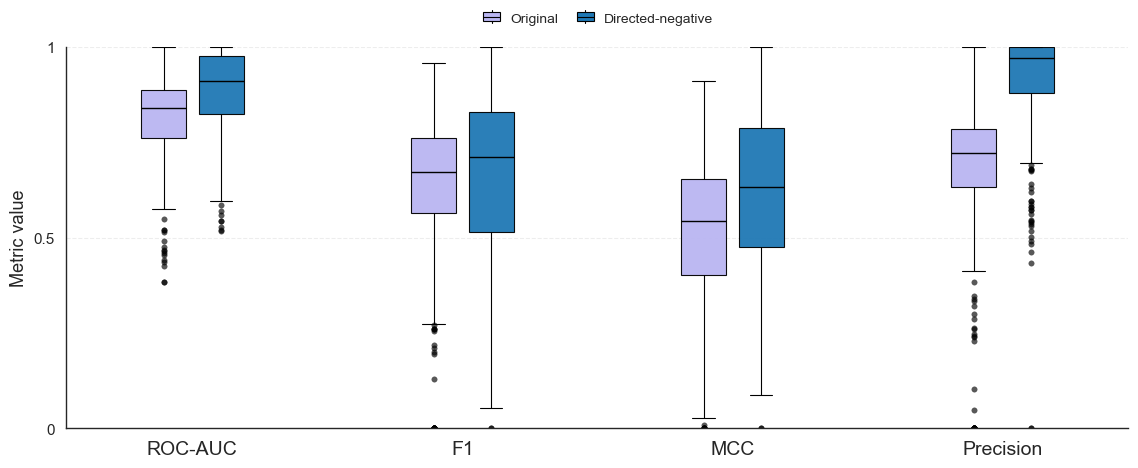

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


sns.set_theme(
    context="paper",
    style="white",
    font_scale=1.1,
)


# ============================================================
# Locate repository root
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    candidates = [start, *start.parents]

    # Fallback for notebooks launched outside the repository.
    fallback = Path(
        "/Users/acw792/Developer/qmul-phd-framework"
    )

    if fallback not in candidates:
        candidates.append(fallback)

    for candidate in candidates:
        if (
            (candidate / "src/matlab").is_dir()
            and (candidate / "docs").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the qmul-phd-framework repository."
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final configuration
# ============================================================

TRAIN_RATIO_TARGET = 90
CLASSIFICATION_THRESHOLD = 0.50
NODES_THRESHOLD = 0

# Tukey is applied across 50 runs.
# At least 50% must remain: ceil(50 × 0.5) = 25 runs.
EXPECTED_RUNS = 50
MINIMUM_RETAINED_FRACTION = 0.50
MINIMUM_RETAINED_RUNS = 25

ELIGIBILITY_MODE = "role_only"
MASS_ELIGIBILITY_ENABLED = False
CHECK_CONNECTIVITY = False
ADAPTIVE_CONNECTIVITY = False

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min50pct_threshold0p50_v1"
)

assert MINIMUM_RETAINED_RUNS == int(
    np.ceil(
        EXPECTED_RUNS
        * MINIMUM_RETAINED_FRACTION
    )
)


# ============================================================
# Result roots
# ============================================================

ORIGINAL_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_original_50x290_train90_thresh0p50_"
        "legacy_uppertriangular_checkconnfalse_adaptivefalse_Apocrita"
    )
)

DIR_NEG_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_sweep_train_ratios_"
        "10-90_pseudo_properties_Apocrita_neg_const"
    )
)


# ============================================================
# Tukey-filtered figure inputs
# ============================================================

ORIGINAL_INPUT = (
    ORIGINAL_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figure_inputs"
    / "predictive_train90_after_tukey.csv"
)

DIR_NEG_INPUT = (
    DIR_NEG_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figure_inputs"
    / "predictive_train90_after_tukey.csv"
)

FOODWEB_CSV = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)


# ============================================================
# Publication output
# ============================================================

OUT_DIR = (
    DIR_NEG_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figures"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_STEM = (
    "figure_3_original_vs_extended_wlnm_"
    "four_metrics_train90_thresh0p50_"
    "tukey_iqr1p5_min50pct"
)

PNG_PATH = OUT_DIR / f"{OUTPUT_STEM}.png"
SVG_PATH = OUT_DIR / f"{OUTPUT_STEM}.svg"
PDF_PATH = OUT_DIR / f"{OUTPUT_STEM}.pdf"

SUMMARY_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_summary.csv"
)

RETENTION_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_retention_counts.csv"
)


# ============================================================
# Metrics
# ============================================================

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
]

METRIC_ORDER = [
    metric
    for metric, _ in METRIC_SPECS
]

METRIC_LABELS = dict(METRIC_SPECS)

VERSION_ORDER = [
    "original",
    "dir_neg",
]

VERSION_LABELS = {
    "original": "Original",
    "dir_neg": "Directed-negative",
}

VERSION_PALETTE = {
    "original": "#BAB6F2",
    "dir_neg": "#1F78B4",
}

SHOW_WEB_LEVEL_FLIERS = True


# ============================================================
# Validate required inputs
# ============================================================

required_inputs = {
    "Corrected WLNM_original Tukey input": ORIGINAL_INPUT,
    "Final WLNM_dir_neg Tukey input": DIR_NEG_INPUT,
    "Food-web metadata": FOODWEB_CSV,
}

missing_inputs = [
    f"{label}:\n  {path}"
    for label, path in required_inputs.items()
    if not path.is_file()
]

if missing_inputs:
    raise FileNotFoundError(
        "The following required inputs are missing:\n\n"
        + "\n\n".join(missing_inputs)
        + (
            "\n\nThe results must first be processed with "
            "apply_wlnm_tukey_retention.py."
        )
    )

print(f"[INFO] Repository: {REPO_ROOT}")
print("[INFO] Using Tukey-filtered inputs:")
print(f"  Original: {ORIGINAL_INPUT}")
print(f"  Directed-negative: {DIR_NEG_INPUT}")


# ============================================================
# Helpers
# ============================================================

def normalize_fw_label(name):
    name = str(name).strip()

    for suffix in [
        ".mat",
        ".csv",
    ]:
        if name.endswith(suffix):
            name = name[: -len(suffix)]

    name = name.replace(" ", "_")

    for token in [
        "_results_",
        "_result_",
        "_results",
        "_random",
        "_tax_mass",
        "_tax",
        "_mass",
    ]:
        name = name.replace(token, "_")

    return "_".join(
        part
        for part in name.split("_")
        if part
    ).lower()


def load_tukey_figure_input(
    path,
    version,
):
    df = pd.read_csv(path)

    required_columns = {
        "Foodweb",
        "Metric",
        "MetricFamily",
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "MinimumRetainedRuns",
        "MeetsMinimumRetainedRuns",
        "TrainRatio",
        "Threshold",
    }

    missing_columns = required_columns.difference(
        df.columns
    )

    if missing_columns:
        raise ValueError(
            f"{path.name} is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    numeric_columns = [
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "MinimumRetainedRuns",
        "MeetsMinimumRetainedRuns",
        "TrainRatio",
        "Threshold",
    ]

    for column in numeric_columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce",
        )

    # --------------------------------------------------------
    # Validate the Tukey preprocessing configuration
    # --------------------------------------------------------

    target_rows = df[
        df["Metric"].isin(METRIC_ORDER)
        & df["MetricFamily"].eq("predictive")
        & np.isclose(
            df["TrainRatio"],
            TRAIN_RATIO_TARGET,
            atol=1e-8,
            equal_nan=False,
        )
        & np.isclose(
            df["Threshold"],
            CLASSIFICATION_THRESHOLD,
            atol=1e-9,
            equal_nan=False,
        )
    ].copy()

    if target_rows.empty:
        raise ValueError(
            f"No predictive rows for train ratio "
            f"{TRAIN_RATIO_TARGET} and threshold "
            f"{CLASSIFICATION_THRESHOLD} were found in:\n{path}"
        )

    observed_minimums = set(
        target_rows["MinimumRetainedRuns"]
        .dropna()
        .astype(int)
        .unique()
    )

    if observed_minimums != {
        MINIMUM_RETAINED_RUNS
    }:
        raise ValueError(
            f"{path.name} was not processed with the "
            f"expected minimum of "
            f"{MINIMUM_RETAINED_RUNS} retained runs. "
            f"Found: {sorted(observed_minimums)}"
        )

    invalid_minimum_rows = target_rows[
        target_rows["MeetsMinimumRetainedRuns"].eq(1)
        & target_rows["RetainedRunsAfterTukey"].lt(
            MINIMUM_RETAINED_RUNS
        )
    ]

    if not invalid_minimum_rows.empty:
        display(
            invalid_minimum_rows[
                [
                    "Foodweb",
                    "Metric",
                    "RetainedRunsAfterTukey",
                    "MinimumRetainedRuns",
                    "MeetsMinimumRetainedRuns",
                ]
            ]
        )

        raise ValueError(
            f"{path.name} marks groups with fewer than "
            f"{MINIMUM_RETAINED_RUNS} runs as retained."
        )

    # --------------------------------------------------------
    # Keep valid Tukey-filtered food-web metric summaries
    # --------------------------------------------------------

    df = target_rows[
        target_rows["MinimumRetainedRuns"].eq(
            MINIMUM_RETAINED_RUNS
        )
        & target_rows["RetainedRunsAfterTukey"].ge(
            MINIMUM_RETAINED_RUNS
        )
        & target_rows["MeetsMinimumRetainedRuns"].eq(1)
        & target_rows["MeanAfterTukey"].notna()
    ].copy()

    if df.empty:
        raise ValueError(
            f"No valid Tukey-filtered rows remain in:\n{path}"
        )

    df["Version"] = version
    df["Value"] = df["MeanAfterTukey"]

    df["FW_KEY"] = (
        df["Foodweb"]
        .apply(normalize_fw_label)
    )

    duplicate_mask = df.duplicated(
        subset=[
            "FW_KEY",
            "Version",
            "Metric",
        ],
        keep=False,
    )

    if duplicate_mask.any():
        duplicated = (
            df.loc[
                duplicate_mask,
                [
                    "Foodweb",
                    "Version",
                    "Metric",
                ],
            ]
            .sort_values(
                [
                    "Metric",
                    "Foodweb",
                ]
            )
        )

        display(duplicated)

        raise ValueError(
            f"Duplicated foodweb–metric rows found in:\n{path}"
        )

    minimum_observed = int(
        df["RetainedRunsAfterTukey"].min()
    )

    maximum_observed = int(
        df["RetainedRunsAfterTukey"].max()
    )

    print(
        f"[INFO] {version}: Tukey requirement validated "
        f"(at least {MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS} runs)."
    )

    print(
        f"       Actual retained-run range: "
        f"{minimum_observed}–{maximum_observed}"
    )

    print(
        f"       Retained food webs: "
        f"{df['FW_KEY'].nunique()}"
    )

    return df


# ============================================================
# Load final Tukey-filtered values
# ============================================================

original_df = load_tukey_figure_input(
    ORIGINAL_INPUT,
    version="original",
)

dir_neg_df = load_tukey_figure_input(
    DIR_NEG_INPUT,
    version="dir_neg",
)

combined_df = pd.concat(
    [
        original_df,
        dir_neg_df,
    ],
    ignore_index=True,
)


# ============================================================
# Apply node-count filter
# ============================================================

metadata_df = pd.read_csv(
    FOODWEB_CSV
)

metadata_df.columns = [
    column.strip()
    for column in metadata_df.columns
]

foodweb_column = next(
    (
        column
        for column in metadata_df.columns
        if column.lower() == "foodweb"
    ),
    None,
)

nodes_column = next(
    (
        column
        for column in metadata_df.columns
        if column.lower() in {
            "nodes",
            "n_nodes",
            "num_nodes",
            "nodecount",
            "s",
        }
    ),
    None,
)

if (
    foodweb_column is None
    or nodes_column is None
):
    raise ValueError(
        "Could not identify Foodweb and Nodes "
        "columns in the metadata file."
    )

metadata_df[nodes_column] = pd.to_numeric(
    metadata_df[nodes_column],
    errors="coerce",
)

metadata_df["FW_KEY"] = (
    metadata_df[foodweb_column]
    .apply(normalize_fw_label)
)

metadata_df = (
    metadata_df[
        [
            "FW_KEY",
            foodweb_column,
            nodes_column,
        ]
    ]
    .drop_duplicates(
        subset=["FW_KEY"]
    )
)

allowed_fw_keys = set(
    metadata_df.loc[
        metadata_df[nodes_column]
        >= NODES_THRESHOLD,
        "FW_KEY",
    ]
)

print(
    f"[INFO] Food webs satisfying "
    f"Nodes >= {NODES_THRESHOLD}: "
    f"{len(allowed_fw_keys)}"
)

combined_df = combined_df[
    combined_df["FW_KEY"]
    .isin(allowed_fw_keys)
].copy()

if combined_df.empty:
    raise RuntimeError(
        "No retained food-web metrics remain "
        "after the node-count filter."
    )


# ============================================================
# Enforce paired food webs separately per metric
# ============================================================

paired_frames = []
pairing_rows = []

for metric in METRIC_ORDER:
    metric_df = combined_df[
        combined_df["Metric"].eq(metric)
    ].copy()

    original_keys = set(
        metric_df.loc[
            metric_df["Version"].eq("original"),
            "FW_KEY",
        ]
    )

    dir_neg_keys = set(
        metric_df.loc[
            metric_df["Version"].eq("dir_neg"),
            "FW_KEY",
        ]
    )

    common_keys = (
        original_keys
        .intersection(dir_neg_keys)
    )

    pairing_rows.append(
        {
            "Metric": METRIC_LABELS[metric],
            "Original retained food webs": len(
                original_keys
            ),
            "Directed-negative retained food webs": len(
                dir_neg_keys
            ),
            "Paired food webs": len(
                common_keys
            ),
            "Original-only food webs": len(
                original_keys
                - dir_neg_keys
            ),
            "Directed-negative-only food webs": len(
                dir_neg_keys
                - original_keys
            ),
        }
    )

    paired_metric_df = metric_df[
        metric_df["FW_KEY"].isin(
            common_keys
        )
    ].copy()

    paired_frames.append(
        paired_metric_df
    )

plot_df = pd.concat(
    paired_frames,
    ignore_index=True,
)

if plot_df.empty:
    raise RuntimeError(
        "No paired food webs remain for plotting."
    )

pairing_table = pd.DataFrame(
    pairing_rows
)

print(
    "\n=== Retained and paired food webs "
    "by metric ==="
)

display(pairing_table)


# ============================================================
# Retention details
# ============================================================

retention_table = (
    plot_df
    .groupby(
        [
            "Version",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FW_KEY",
            "nunique",
        ),
        MinimumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "min",
        ),
        MedianRetainedRuns=(
            "RetainedRunsAfterTukey",
            "median",
        ),
        MaximumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "max",
        ),
    )
)

retention_table["Version"] = (
    retention_table["Version"]
    .map(VERSION_LABELS)
)

retention_table["Metric"] = (
    retention_table["Metric"]
    .map(METRIC_LABELS)
)

retention_table = retention_table[
    [
        "Version",
        "Metric",
        "FoodWebs",
        "MinimumRetainedRuns",
        "MedianRetainedRuns",
        "MaximumRetainedRuns",
    ]
]

print(
    "\n=== Tukey retention details "
    "for paired food webs ==="
)

display(retention_table)


# ============================================================
# Web-level summary
# ============================================================

summary_table = (
    plot_df
    .groupby(
        [
            "Version",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FW_KEY",
            "nunique",
        ),
        Mean=(
            "Value",
            "mean",
        ),
        Median=(
            "Value",
            "median",
        ),
        SD=(
            "Value",
            "std",
        ),
        Variance=(
            "Value",
            "var",
        ),
    )
)

summary_table["Version"] = (
    summary_table["Version"]
    .map(VERSION_LABELS)
)

summary_table["Metric"] = (
    summary_table["Metric"]
    .map(METRIC_LABELS)
)

for column in [
    "Mean",
    "Median",
    "SD",
    "Variance",
]:
    summary_table[column] = (
        summary_table[column]
        .round(4)
    )

print(
    "\n=== Tukey-filtered web-level "
    "predictive metric summary ==="
)

display(summary_table)


# ============================================================
# Custom miniature boxplot legend
# ============================================================

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans,
    ):
        facecolor = orig_handle["facecolor"]

        edgecolor = orig_handle.get(
            "edgecolor",
            "black",
        )

        linewidth = orig_handle.get(
            "linewidth",
            0.6,
        )

        center_x = (
            xdescent
            + 0.5 * width
        )

        center_y = (
            ydescent
            + 0.44 * height
        )

        box_width = (
            0.8 * width
        )

        box_height = (
            0.8 * height
        )

        box_x = (
            center_x
            - box_width / 2
        )

        box_y = (
            center_y
            - box_height / 2
        )

        whisker_top_y = (
            box_y
            + box_height
            + 0.18 * height
        )

        whisker_bottom_y = (
            box_y
            - 0.18 * height
        )

        box = Rectangle(
            (
                box_x,
                box_y,
            ),
            box_width,
            box_height,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [
                box_x,
                box_x + box_width,
            ],
            [
                center_y,
                center_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        upper_whisker = Line2D(
            [
                center_x,
                center_x,
            ],
            [
                box_y + box_height,
                whisker_top_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        lower_whisker = Line2D(
            [
                center_x,
                center_x,
            ],
            [
                whisker_bottom_y,
                box_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [
            box,
            median,
            upper_whisker,
            lower_whisker,
        ]


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(11.5, 4.8)
)

group_gap = 1.5

group_centers = (
    1.0
    + np.arange(
        len(METRIC_SPECS)
    )
    * group_gap
)

offsets = {
    "original": -0.16,
    "dir_neg": 0.16,
}

box_width = 0.25

for version in VERSION_ORDER:
    version_data = []
    version_positions = []

    for metric_index, (
        metric,
        metric_label,
    ) in enumerate(METRIC_SPECS):
        values = (
            plot_df.loc[
                (
                    plot_df["Version"].eq(
                        version
                    )
                )
                & (
                    plot_df["Metric"].eq(
                        metric
                    )
                ),
                "Value",
            ]
            .dropna()
            .to_numpy()
        )

        if len(values) == 0:
            continue

        version_data.append(
            values
        )

        version_positions.append(
            group_centers[metric_index]
            + offsets[version]
        )

    if not version_data:
        raise RuntimeError(
            f"No plotting values found for version: {version}"
        )

    ax.boxplot(
        version_data,
        positions=version_positions,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=SHOW_WEB_LEVEL_FLIERS,
        boxprops={
            "facecolor": VERSION_PALETTE[version],
            "edgecolor": "black",
            "linewidth": 0.8,
            "alpha": 0.95,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.0,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.8,
        },
        capprops={
            "color": "black",
            "linewidth": 0.8,
        },
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.2,
            "alpha": 0.65,
        },
    )


# ============================================================
# Axes and legend
# ============================================================

legend_handles = [
    {
        "facecolor": VERSION_PALETTE[version],
        "edgecolor": "black",
        "linewidth": 0.8,
    }
    for version in VERSION_ORDER
]

ax.set_xlim(
    group_centers[0] - 0.7,
    group_centers[-1] + 0.7,
)

ax.set_ylim(
    0,
    1.0,
)

ax.set_xticks(
    group_centers,
    labels=[
        metric_label
        for _, metric_label in METRIC_SPECS
    ],
)

plt.setp(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=14,
)

ax.set_ylabel(
    "Metric value",
    fontsize=13,
)

ax.set_xlabel("")

ax.set_yticks(
    [
        0,
        0.5,
        1.0,
    ]
)

ax.set_yticklabels(
    [
        "0",
        "0.5",
        "1",
    ]
)

ax.tick_params(
    axis="y",
    labelsize=11,
)

ax.grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.35,
)

ax.legend(
    handles=legend_handles,
    labels=[
        VERSION_LABELS[version]
        for version in VERSION_ORDER
    ],
    handler_map={
        dict: HandlerMiniBoxplot()
    },
    loc="lower center",
    bbox_to_anchor=(
        0.5,
        1.03,
    ),
    ncol=len(VERSION_ORDER),
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
    columnspacing=1.2,
)

sns.despine(
    ax=ax
)

plt.tight_layout()


# ============================================================
# Export
# ============================================================

fig.savefig(
    PNG_PATH,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    SVG_PATH,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
    facecolor="white",
)

summary_table.to_csv(
    SUMMARY_PATH,
    index=False,
)

retention_table.to_csv(
    RETENTION_PATH,
    index=False,
)

print(
    "\n[INFO] Saved publication-ready outputs:"
)

print(f"  PNG: {PNG_PATH}")
print(f"  SVG: {SVG_PATH}")
print(f"  PDF: {PDF_PATH}")
print(f"  Summary: {SUMMARY_PATH}")
print(f"  Retention counts: {RETENTION_PATH}")

print(
    "\n[INFO] Final directed configuration:"
)

print(
    f"  check_connectivity={CHECK_CONNECTIVITY}"
)

print(
    f"  adaptive_connectivity={ADAPTIVE_CONNECTIVITY}"
)

print(
    f"  classification_threshold="
    f"{CLASSIFICATION_THRESHOLD}"
)

print(
    f"  retention_protocol={PROTOCOL_NAME}"
)

print(
    f"  minimum_retained_runs="
    f"{MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS}"
)

plt.show()

[INFO] Repository: /Users/acw792/Developer/qmul-phd-framework
[INFO] Result root: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const
[INFO] Tukey input: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figure_inputs/predictive_train10-90_after_tukey.csv
[INFO] Validated final role-only configuration:
  scenario=role_only_5_role_constraints_checkconnfalse_adaptivefalse_threshold0p50
  eligibility=role_only
  mass_eligibility_enabled=false
  negative_sampling=uniform_role_pool_then_uniform_remaining_nonlinks_topup
  target_negative_positive_ratio=2
  classification_threshold=0.50
  check_connectivity=false
  adaptive_connectivity=false
  number_of_experiments=50
  train_ratio_range=0.10:0.10:0.90
  retention_protocol=tukey_iqr_1p5_min50pct_threshold0p

,TRAINRATIO,Metric,MetricLabel,FoodWebs,MinimumRetainedRuns,MedianRetainedRuns,MaximumRetainedRuns
0,10,F1Score,F1,290,38,50.0,50
1,10,Precision,Precision,290,38,49.0,50
2,10,ROC_AUC,ROC-AUC,290,41,49.0,50
3,10,TestMCC,MCC,290,29,50.0,50
4,20,F1Score,F1,290,44,50.0,50
5,20,Precision,Precision,290,37,50.0,50
6,20,ROC_AUC,ROC-AUC,290,41,49.0,50
7,20,TestMCC,MCC,290,44,50.0,50
8,30,F1Score,F1,290,40,50.0,50
9,30,Precision,Precision,290,43,50.0,50


[INFO] Food webs represented: 290

[INFO] Saved publication-ready outputs:
  PNG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/figure_4_predictive_four_metrics_by_train_ratio_roleonly_5constraints_checkconnfalse_adaptivefalse_thresh0p50_tukey_iqr1p5_min50pct.png
  SVG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/figure_4_predictive_four_metrics_by_train_ratio_roleonly_5constraints_checkconnfalse_adaptivefalse_thresh0p50_tukey_iqr1p5_min50pct.svg
  PDF: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/figure_4

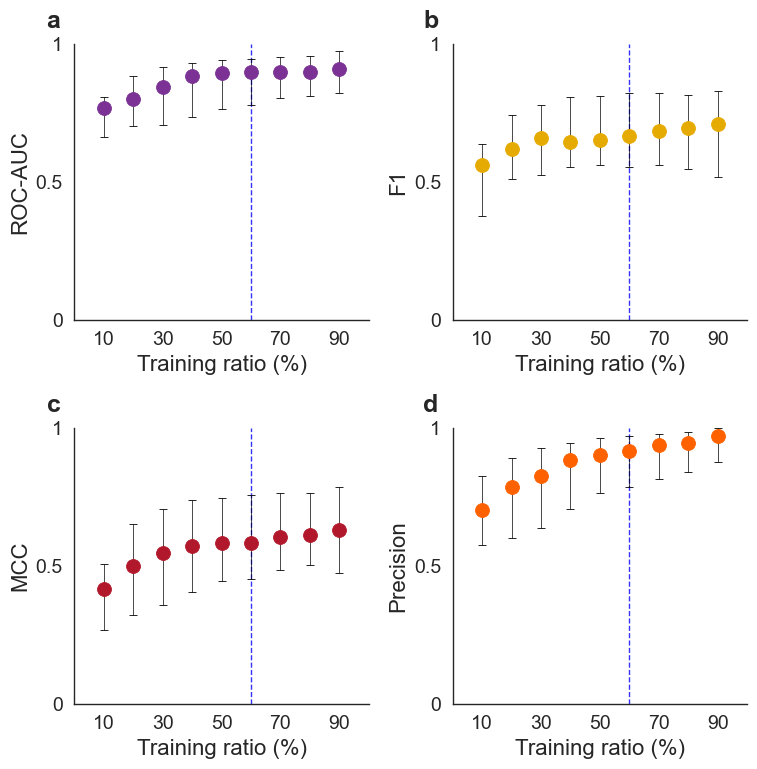

In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display


sns.set_context(
    "paper",
    font_scale=1.35,
)

sns.set_style("white")


# ============================================================
# Locate repository root
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    candidates = [start, *start.parents]

    fallback = Path(
        "/Users/acw792/Developer/qmul-phd-framework"
    )

    if fallback not in candidates:
        candidates.append(fallback)

    for candidate in candidates:
        if (
            (candidate / "src/matlab").is_dir()
            and (candidate / "docs").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the qmul-phd-framework repository."
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final role-only experimental configuration
# ============================================================

CHECK_CONNECTIVITY = False
ADAPTIVE_CONNECTIVITY = False
CLASSIFICATION_THRESHOLD = 0.50

NODES_THRESHOLD = 0

# Tukey is applied independently across 50 runs for each
# Foodweb × TrainRatio × Metric group.
EXPECTED_RUNS = 50
MINIMUM_RETAINED_FRACTION = 0.50
MINIMUM_RETAINED_RUNS = 25

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min50pct_threshold0p50_v1"
)

EXPECTED_SCENARIO = (
    "role_only_5_role_constraints_"
    "checkconnfalse_adaptivefalse_threshold0p50"
)

calculated_minimum_runs = int(
    np.ceil(
        EXPECTED_RUNS
        * MINIMUM_RETAINED_FRACTION
    )
)

assert calculated_minimum_runs == MINIMUM_RETAINED_RUNS, (
    "The configured minimum retained runs is inconsistent "
    "with the expected number of runs and retained fraction."
)


# ============================================================
# Final role-only result root
# ============================================================

RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_sweep_train_ratios_"
        "10-90_pseudo_properties_Apocrita_neg_const"
    )
)

RETENTION_ROOT = (
    RESULT_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
)

RETENTION_MANIFEST_PATH = (
    RETENTION_ROOT
    / "retention_manifest.json"
)

RESULTS_FILE = (
    RETENTION_ROOT
    / "figure_inputs"
    / "predictive_train10-90_after_tukey.csv"
)

FOODWEB_CSV = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)


# ============================================================
# Output paths
# ============================================================

OUT_DIR = (
    RETENTION_ROOT
    / "figures"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_STEM = (
    "figure_4_predictive_four_metrics_by_train_ratio_"
    "roleonly_5constraints_checkconnfalse_"
    "adaptivefalse_thresh0p50_"
    "tukey_iqr1p5_min50pct"
)

PNG_PATH = OUT_DIR / f"{OUTPUT_STEM}.png"
SVG_PATH = OUT_DIR / f"{OUTPUT_STEM}.svg"
PDF_PATH = OUT_DIR / f"{OUTPUT_STEM}.pdf"

SUMMARY_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_summary.csv"
)

RETENTION_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_retention.csv"
)


# ============================================================
# Metrics
# ============================================================

METRICS = [
    "ROC_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
]

METRIC_LABELS = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
}

METRIC_PALETTE = {
    "ROC-AUC": "#7B3294",
    "PR-AUC": "#C51B7D",
    "F1": "#E6AB02",
    "MCC": "#B2182B",
    "Precision": "#FE6100",
    "Recall": "#CAB2D6",
    "TSS": "#666666",
}

SHOW_GRID = False

Y_MIN = 0.0
Y_MAX = 1.0

INDEPENDENT_Y = False
Y_PADDING = 0.02

REFERENCE_TRAIN_RATIO = 60


# ============================================================
# Validate required files
# ============================================================

required_files = {
    "Tukey retention manifest": RETENTION_MANIFEST_PATH,
    "Tukey-filtered predictive input": RESULTS_FILE,
    "Food-web metadata": FOODWEB_CSV,
}

missing_files = [
    f"{label}:\n  {path}"
    for label, path in required_files.items()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "The following required files are missing:\n\n"
        + "\n\n".join(missing_files)
    )

print(f"[INFO] Repository: {REPO_ROOT}")
print(f"[INFO] Result root: {RESULT_ROOT}")
print(f"[INFO] Tukey input: {RESULTS_FILE}")


# ============================================================
# Validate final role-only configuration
# ============================================================

with RETENTION_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    retention_manifest = json.load(file)

manifest = retention_manifest.get(
    "source_manifest",
    {},
)

expected_manifest = {
    "Version": "WLNM_dir_neg",
    "Condition": EXPECTED_SCENARIO,
    "Eligibility": "role_only",
    "MassEligibilityEnabled": "false",
    "NegativeSampling": (
        "uniform_role_pool_then_uniform_remaining_nonlinks_topup"
    ),
    "TargetNegativePositiveRatio": "2",
    "NumExperiments": str(EXPECTED_RUNS),
    "TrainRatioRange": "0.10:0.10:0.90",
    "ClassificationThreshold": "0.50",
    "CheckConnectivity": "false",
    "AdaptiveConnectivity": "false",
    "FoodWebs": "290",
}

configuration_errors = []

for key, expected_value in expected_manifest.items():
    observed_value = manifest.get(key)

    if observed_value != expected_value:
        configuration_errors.append(
            f"{key}: expected {expected_value!r}, "
            f"observed {observed_value!r}"
        )

if configuration_errors:
    raise ValueError(
        "The selected result root does not match the "
        "final role-only configuration:\n\n"
        + "\n".join(configuration_errors)
    )

observed_scenario = retention_manifest.get(
    "scenario"
)

if observed_scenario != EXPECTED_SCENARIO:
    raise ValueError(
        "Unexpected scenario in retention_manifest.json:\n"
        f"  expected: {EXPECTED_SCENARIO}\n"
        f"  observed: {observed_scenario}"
    )

observed_threshold = retention_manifest.get(
    "classification_threshold"
)

if observed_threshold is None or not np.isclose(
    float(observed_threshold),
    CLASSIFICATION_THRESHOLD,
    atol=1e-9,
):
    raise ValueError(
        "The Tukey retention threshold does not match "
        f"{CLASSIFICATION_THRESHOLD:.2f}."
    )

observed_minimum_fraction = retention_manifest.get(
    "minimum_retained_fraction"
)

if observed_minimum_fraction is None or not np.isclose(
    float(observed_minimum_fraction),
    MINIMUM_RETAINED_FRACTION,
    atol=1e-12,
):
    raise ValueError(
        "The Tukey minimum retained fraction does not match:\n"
        f"  expected: {MINIMUM_RETAINED_FRACTION}\n"
        f"  observed: {observed_minimum_fraction}"
    )

observed_standard_example = retention_manifest.get(
    "standard_minimum_example"
)

expected_standard_example = (
    f"{MINIMUM_RETAINED_RUNS} of {EXPECTED_RUNS}"
)

if (
    observed_standard_example is not None
    and observed_standard_example
    != expected_standard_example
):
    raise ValueError(
        "Unexpected standard Tukey minimum in manifest:\n"
        f"  expected: {expected_standard_example}\n"
        f"  observed: {observed_standard_example}"
    )

print(
    "[INFO] Validated final role-only configuration:"
)

print(f"  scenario={manifest['Condition']}")
print(f"  eligibility={manifest['Eligibility']}")

print(
    "  mass_eligibility_enabled="
    f"{manifest['MassEligibilityEnabled']}"
)

print(
    "  negative_sampling="
    f"{manifest['NegativeSampling']}"
)

print(
    "  target_negative_positive_ratio="
    f"{manifest['TargetNegativePositiveRatio']}"
)

print(
    "  classification_threshold="
    f"{manifest['ClassificationThreshold']}"
)

print(
    "  check_connectivity="
    f"{manifest['CheckConnectivity']}"
)

print(
    "  adaptive_connectivity="
    f"{manifest['AdaptiveConnectivity']}"
)

print(
    "  number_of_experiments="
    f"{manifest['NumExperiments']}"
)

print(
    "  train_ratio_range="
    f"{manifest['TrainRatioRange']}"
)

print(f"  retention_protocol={PROTOCOL_NAME}")

print(
    "  minimum_retained_fraction="
    f"{MINIMUM_RETAINED_FRACTION:.2f}"
)

print(
    "  minimum_retained_runs="
    f"{MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS}"
)


# ============================================================
# Food-web name normalisation
# ============================================================

def normalize_fw_label(name):
    name = str(name).strip()

    for suffix in [
        ".mat",
        ".csv",
    ]:
        if name.endswith(suffix):
            name = name[: -len(suffix)]

    name = name.replace(
        " ",
        "_",
    )

    for token in [
        "_results_",
        "_result_",
        "_results",
        "_random",
        "_tax_mass",
        "_tax",
        "_mass",
    ]:
        name = name.replace(
            token,
            "_",
        )

    return "_".join(
        part
        for part in name.split("_")
        if part
    ).lower()


# ============================================================
# Load Tukey-filtered web-level results
# ============================================================

df = pd.read_csv(
    RESULTS_FILE
)

required_columns = {
    "Scenario",
    "Foodweb",
    "Version",
    "Metric",
    "MetricLabel",
    "MetricFamily",
    "TrainRatio",
    "Threshold",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "MinimumRetainedRuns",
    "MeetsMinimumRetainedRuns",
}

missing_columns = required_columns.difference(
    df.columns
)

if missing_columns:
    raise ValueError(
        f"{RESULTS_FILE.name} is missing required columns: "
        f"{sorted(missing_columns)}"
    )

numeric_columns = [
    "TrainRatio",
    "Threshold",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "MinimumRetainedRuns",
    "MeetsMinimumRetainedRuns",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce",
    )


# ============================================================
# Select the final role-only configuration
# ============================================================

target_df = df[
    df["Scenario"].eq(
        EXPECTED_SCENARIO
    )
    & df["Version"].eq(
        "WLNM_dir_neg"
    )
    & df["MetricFamily"].eq(
        "predictive"
    )
    & df["Metric"].isin(
        METRICS
    )
    & np.isclose(
        df["Threshold"],
        CLASSIFICATION_THRESHOLD,
        atol=1e-9,
        equal_nan=False,
    )
].copy()

if target_df.empty:
    raise RuntimeError(
        "No predictive results match the final "
        "role-only configuration."
    )


# ============================================================
# Validate minimum 25 retained runs
# ============================================================

observed_minimums = set(
    target_df["MinimumRetainedRuns"]
    .dropna()
    .astype(int)
    .unique()
)

if observed_minimums != {
    MINIMUM_RETAINED_RUNS
}:
    raise ValueError(
        "The Tukey figure input was not processed with "
        f"the expected minimum of "
        f"{MINIMUM_RETAINED_RUNS} retained runs.\n"
        f"Observed values: {sorted(observed_minimums)}"
    )

incorrect_retention = target_df[
    target_df["MeetsMinimumRetainedRuns"].eq(1)
    & target_df["RetainedRunsAfterTukey"].lt(
        MINIMUM_RETAINED_RUNS
    )
]

if not incorrect_retention.empty:
    display(
        incorrect_retention[
            [
                "Foodweb",
                "TrainRatio",
                "Metric",
                "RetainedRunsAfterTukey",
                "MinimumRetainedRuns",
                "MeetsMinimumRetainedRuns",
            ]
        ]
    )

    raise ValueError(
        "At least one group is marked as retained despite "
        f"having fewer than {MINIMUM_RETAINED_RUNS} runs."
    )

below_minimum = target_df[
    target_df["RetainedRunsAfterTukey"].lt(
        MINIMUM_RETAINED_RUNS
    )
]

if not below_minimum.empty:
    print(
        "[INFO] Groups excluded because fewer than "
        f"{MINIMUM_RETAINED_RUNS} runs remained: "
        f"{len(below_minimum):,}"
    )


# ============================================================
# Keep valid Tukey-filtered groups
# ============================================================

df = target_df[
    target_df["MinimumRetainedRuns"].eq(
        MINIMUM_RETAINED_RUNS
    )
    & target_df["RetainedRunsAfterTukey"].ge(
        MINIMUM_RETAINED_RUNS
    )
    & target_df["MeetsMinimumRetainedRuns"].eq(1)
    & target_df["MeanAfterTukey"].notna()
].copy()

if df.empty:
    raise RuntimeError(
        "No retained predictive results remain after "
        "validating the Tukey minimum."
    )

print(
    "[INFO] Tukey minimum validated: "
    f"at least {MINIMUM_RETAINED_RUNS} of "
    f"{EXPECTED_RUNS} runs per food web and metric."
)

print(
    "[INFO] Actual retained-run range: "
    f"{int(df['RetainedRunsAfterTukey'].min())}–"
    f"{int(df['RetainedRunsAfterTukey'].max())}"
)


# ============================================================
# Prepare plotting variables
# ============================================================

df["TRAINRATIO"] = (
    df["TrainRatio"]
    .round()
    .astype(int)
)

df["Value"] = (
    df["MeanAfterTukey"]
)

df["FW_KEY"] = (
    df["Foodweb"]
    .apply(normalize_fw_label)
)


# ============================================================
# Validate expected training ratios
# ============================================================

expected_train_ratios = list(
    range(
        10,
        100,
        10,
    )
)

observed_train_ratios = sorted(
    df["TRAINRATIO"]
    .dropna()
    .unique()
    .tolist()
)

if observed_train_ratios != expected_train_ratios:
    raise ValueError(
        "Unexpected training-ratio coverage:\n"
        f"  expected: {expected_train_ratios}\n"
        f"  observed: {observed_train_ratios}"
    )


# ============================================================
# Validate unique web-level observations
# ============================================================

duplicate_mask = df.duplicated(
    subset=[
        "FW_KEY",
        "TRAINRATIO",
        "Metric",
    ],
    keep=False,
)

if duplicate_mask.any():
    duplicated = (
        df.loc[
            duplicate_mask,
            [
                "Foodweb",
                "TRAINRATIO",
                "Metric",
            ],
        ]
        .sort_values(
            [
                "Metric",
                "TRAINRATIO",
                "Foodweb",
            ]
        )
    )

    display(duplicated)

    raise ValueError(
        "Duplicated Foodweb × TrainRatio × Metric "
        "rows were found."
    )


# ============================================================
# Load food-web metadata
# ============================================================

metadata = pd.read_csv(
    FOODWEB_CSV
)

metadata.columns = [
    column.strip()
    for column in metadata.columns
]

foodweb_column = next(
    (
        column
        for column in metadata.columns
        if column.lower() == "foodweb"
    ),
    None,
)

nodes_column = next(
    (
        column
        for column in metadata.columns
        if column.lower() in {
            "nodes",
            "n_nodes",
            "num_nodes",
            "nodecount",
            "s",
        }
    ),
    None,
)

ecosystem_column = next(
    (
        column
        for column in metadata.columns
        if column.lower() in {
            "ecosystem",
            "ecosystemtype",
            "ecosystem_type",
        }
    ),
    None,
)

if (
    foodweb_column is None
    or nodes_column is None
    or ecosystem_column is None
):
    raise ValueError(
        "Could not identify Foodweb, Nodes, and "
        "Ecosystem columns in the metadata."
    )

metadata[nodes_column] = pd.to_numeric(
    metadata[nodes_column],
    errors="coerce",
)

metadata["FW_KEY"] = (
    metadata[foodweb_column]
    .apply(normalize_fw_label)
)

duplicate_metadata = metadata.duplicated(
    subset=["FW_KEY"],
    keep=False,
)

if duplicate_metadata.any():
    inconsistent_metadata = (
        metadata.loc[
            duplicate_metadata,
            [
                "FW_KEY",
                nodes_column,
                ecosystem_column,
            ],
        ]
        .groupby("FW_KEY")
        .nunique(
            dropna=False
        )
    )

    inconsistent_metadata = inconsistent_metadata[
        (
            inconsistent_metadata[nodes_column] > 1
        )
        | (
            inconsistent_metadata[
                ecosystem_column
            ] > 1
        )
    ]

    if not inconsistent_metadata.empty:
        display(
            inconsistent_metadata
        )

        raise ValueError(
            "Conflicting metadata were found for one or "
            "more normalised food-web names."
        )

metadata = (
    metadata[
        [
            "FW_KEY",
            nodes_column,
            ecosystem_column,
        ]
    ]
    .drop_duplicates(
        subset=["FW_KEY"]
    )
    .rename(
        columns={
            nodes_column: "Nodes",
            ecosystem_column: "Ecosystem",
        }
    )
)


# ============================================================
# Merge metadata and apply node filter
# ============================================================

df = df.merge(
    metadata,
    on="FW_KEY",
    how="left",
    validate="many_to_one",
)

missing_metadata = (
    df.loc[
        (
            df["Nodes"].isna()
            | df["Ecosystem"].isna()
        ),
        "Foodweb",
    ]
    .drop_duplicates()
    .sort_values()
)

if not missing_metadata.empty:
    display(
        missing_metadata.to_frame(
            name="Foodweb"
        )
    )

    raise ValueError(
        "Food-web metadata could not be matched for "
        f"{len(missing_metadata)} food webs."
    )

df = df[
    df["Nodes"] >= NODES_THRESHOLD
].copy()

if df.empty:
    raise RuntimeError(
        f"No food webs remain after applying "
        f"Nodes >= {NODES_THRESHOLD}."
    )

print(
    f"[INFO] Food webs after node filter: "
    f"{df['FW_KEY'].nunique()}"
)

print(
    "[INFO] Training ratios: "
    f"{sorted(df['TRAINRATIO'].unique().tolist())}"
)

print(
    "[INFO] Ecosystems: "
    f"{sorted(df['Ecosystem'].dropna().unique().tolist())}"
)


# ============================================================
# Retention report
# ============================================================

retention_table = (
    df
    .groupby(
        [
            "TRAINRATIO",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FW_KEY",
            "nunique",
        ),
        MinimumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "min",
        ),
        MedianRetainedRuns=(
            "RetainedRunsAfterTukey",
            "median",
        ),
        MaximumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "max",
        ),
    )
)

retention_table["MetricLabel"] = (
    retention_table["Metric"]
    .map(METRIC_LABELS)
)

retention_table = retention_table[
    [
        "TRAINRATIO",
        "Metric",
        "MetricLabel",
        "FoodWebs",
        "MinimumRetainedRuns",
        "MedianRetainedRuns",
        "MaximumRetainedRuns",
    ]
]

print(
    "\n=== Tukey retention by training ratio "
    "and metric ==="
)

display(
    retention_table
)


# ============================================================
# Across-food-web summary
# ============================================================

summary = (
    df
    .groupby(
        [
            "TRAINRATIO",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        median=(
            "Value",
            "median",
        ),
        q25=(
            "Value",
            lambda values: values.quantile(
                0.25
            ),
        ),
        q75=(
            "Value",
            lambda values: values.quantile(
                0.75
            ),
        ),
        mean=(
            "Value",
            "mean",
        ),
        sd=(
            "Value",
            "std",
        ),
        n_webs=(
            "FW_KEY",
            "nunique",
        ),
    )
)

summary["MetricLabel"] = (
    summary["Metric"]
    .map(METRIC_LABELS)
)

train_ratios = sorted(
    summary["TRAINRATIO"]
    .unique()
    .tolist()
)

print(
    f"[INFO] Food webs represented: "
    f"{df['FW_KEY'].nunique()}"
)


# ============================================================
# Consistent metric colours
# ============================================================

metric_colors = {
    metric: METRIC_PALETTE[
        METRIC_LABELS[metric]
    ]
    for metric in METRICS
}


# ============================================================
# Final plot
# ============================================================

number_of_metrics = len(
    METRICS
)

number_of_rows = 2

number_of_columns = int(
    np.ceil(
        number_of_metrics
        / number_of_rows
    )
)

fig, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(
        4 * number_of_columns,
        8.0,
    ),
    sharex=False,
    sharey=False,
)

axes = np.asarray(
    axes
).reshape(
    number_of_rows,
    number_of_columns,
)

axes_flat = axes.flatten()

panel_letters = list(
    "abcdefghijklmnopqrstuvwxyz"
)

for index, metric in enumerate(
    METRICS
):
    ax = axes_flat[index]

    panel_df = (
        summary[
            summary["Metric"].eq(
                metric
            )
        ]
        .sort_values(
            "TRAINRATIO"
        )
    )

    if panel_df.empty:
        ax.set_axis_off()
        continue

    x_values = (
        panel_df["TRAINRATIO"]
        .to_numpy()
    )

    median_values = (
        panel_df["median"]
        .to_numpy()
    )

    error_values = np.vstack(
        [
            (
                panel_df["median"]
                - panel_df["q25"]
            ).to_numpy(),
            (
                panel_df["q75"]
                - panel_df["median"]
            ).to_numpy(),
        ]
    )

    color = metric_colors[
        metric
    ]

    ax.errorbar(
        x_values,
        median_values,
        yerr=error_values,
        fmt="o",
        linestyle="none",
        color=color,
        ecolor="black",
        markersize=10,
        linewidth=1.2,
        elinewidth=0.5,
        capsize=3,
        capthick=0.8,
        markerfacecolor=color,
        markeredgecolor=color,
        markeredgewidth=0.6,
    )

    ax.axvline(
        x=REFERENCE_TRAIN_RATIO,
        color="blue",
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
        zorder=0,
    )

    if INDEPENDENT_Y:
        local_minimum = max(
            Y_MIN,
            panel_df["q25"].min()
            - Y_PADDING,
        )

        local_maximum = min(
            Y_MAX,
            panel_df["q75"].max()
            + Y_PADDING,
        )

        if np.isclose(
            local_minimum,
            local_maximum,
        ):
            local_minimum = max(
                Y_MIN,
                local_minimum
                - 0.02,
            )

            local_maximum = min(
                Y_MAX,
                local_maximum
                + 0.02,
            )

        ax.set_ylim(
            local_minimum,
            local_maximum,
        )

    else:
        ax.set_ylim(
            Y_MIN,
            Y_MAX,
        )

        ax.set_yticks(
            [
                0,
                0.5,
                1.0,
            ]
        )

        ax.set_yticklabels(
            [
                "0",
                "0.5",
                "1",
            ]
        )

    if SHOW_GRID:
        ax.grid(
            True,
            axis="y",
            linestyle="--",
            alpha=0.30,
        )
    else:
        ax.grid(
            False
        )

    visible_ticks = [
        ratio
        for ratio in [
            10,
            30,
            50,
            70,
            90,
        ]
        if ratio in train_ratios
    ]

    ax.set_xticks(
        visible_ticks
    )

    ax.set_xticklabels(
        [
            str(ratio)
            for ratio in visible_ticks
        ]
    )

    ax.set_xlim(
        min(train_ratios) - 10,
        max(train_ratios) + 10,
    )

    ax.set_xlabel(
        "Training ratio (%)",
        fontsize=16,
    )

    ax.set_ylabel(
        METRIC_LABELS[metric],
        fontsize=16,
    )

    ax.set_title("")

    if index < len(
        panel_letters
    ):
        ax.annotate(
            panel_letters[index],
            xy=(0, 1),
            xycoords="axes fraction",
            xytext=(-10, 8),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=18,
            fontweight="bold",
            annotation_clip=False,
        )

    ax.tick_params(
        axis="both",
        labelsize=14,
    )

    sns.despine(
        ax=ax
    )


# ============================================================
# Hide unused panels
# ============================================================

for index in range(
    number_of_metrics,
    len(axes_flat),
):
    axes_flat[index].set_axis_off()


# ============================================================
# Layout and export
# ============================================================

fig.tight_layout(
    rect=[
        0.03,
        0,
        1,
        0.985,
    ]
)

fig.savefig(
    PNG_PATH,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    SVG_PATH,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
    facecolor="white",
)

summary.to_csv(
    SUMMARY_PATH,
    index=False,
)

retention_table.to_csv(
    RETENTION_PATH,
    index=False,
)

print(
    "\n[INFO] Saved publication-ready outputs:"
)

print(f"  PNG: {PNG_PATH}")
print(f"  SVG: {SVG_PATH}")
print(f"  PDF: {PDF_PATH}")
print(f"  Summary: {SUMMARY_PATH}")
print(f"  Retention: {RETENTION_PATH}")

print(
    "\n[INFO] Final Tukey configuration:"
)

print(
    f"  expected_runs="
    f"{EXPECTED_RUNS}"
)

print(
    f"  minimum_retained_fraction="
    f"{MINIMUM_RETAINED_FRACTION:.2f}"
)

print(
    f"  minimum_retained_runs="
    f"{MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS}"
)

plt.show()

[INFO] Repository: /Users/acw792/Developer/qmul-phd-framework
[INFO] Result root: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const
[INFO] Ecological Tukey input: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figure_inputs/ecological_train60_after_tukey.csv
[INFO] Validated final role-only configuration:
  scenario=role_only_5_role_constraints_checkconnfalse_adaptivefalse_threshold0p50
  eligibility=role_only
  mass_eligibility_enabled=false
  negative_sampling=uniform_role_pool_then_uniform_remaining_nonlinks_topup
  target_negative_positive_ratio=2
  classification_threshold=0.50
  check_connectivity=false
  adaptive_connectivity=false
  number_of_experiments=50
  train_ratio_range=0.10:0.10:0.90
  retention_protocol=tukey_iqr_1p5_min50pct_thr

,Metric,FoodWebs,RequiredMinimumRuns,TotalPseudoRunOutliersRemoved,MinRetainedRuns,MedianRetainedRuns,MaxRetainedRuns
0,Connectance,290,25,296,37,50.0,50
1,MeanGenerality,290,25,350,40,49.0,50
2,MeanTrophicHeight,288,25,905,31,46.0,50
3,MeanVulnerability,290,25,257,41,50.0,50


[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/fig5_wlnm_dir_neg_train60_roleonly_5constraints_checkconnfalse_adaptivefalse_threshold0p50_tukey_filtered.png
[INFO] Final Tukey configuration:
  expected_runs=50
  minimum_retained_fraction=0.50
  minimum_retained_runs=25/50


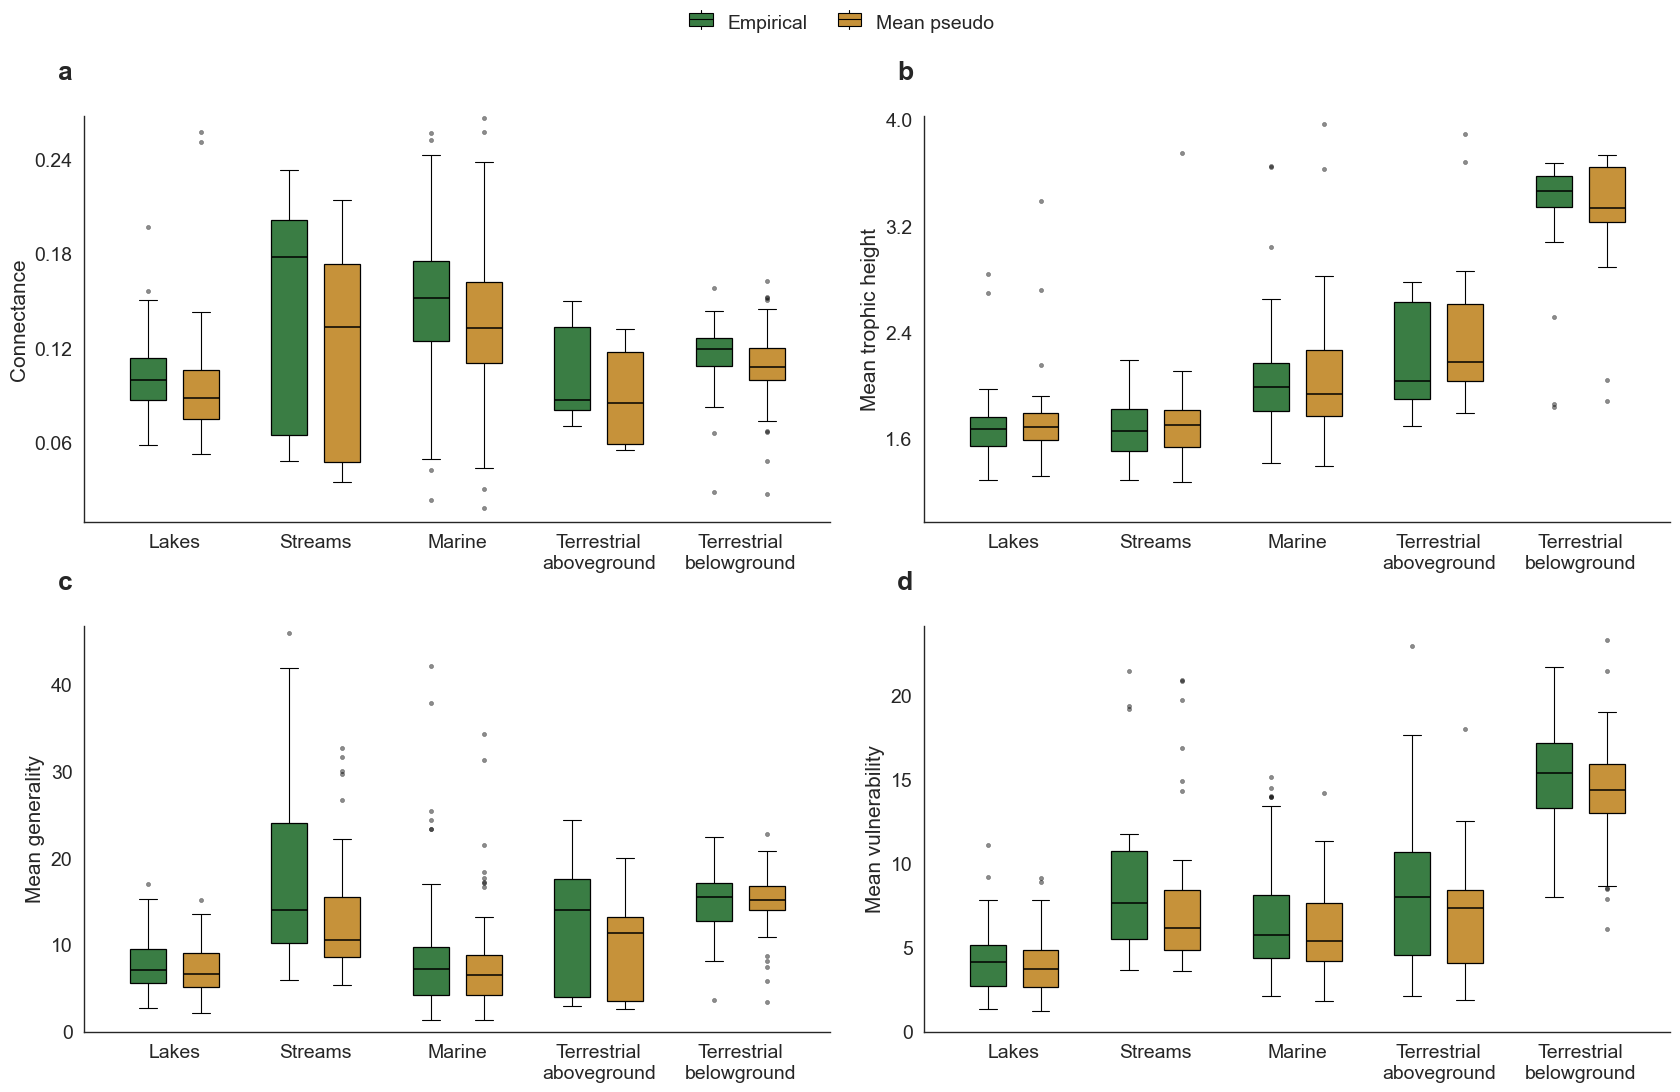

In [3]:
import json
import math

import numpy as np
import pandas as pd
import scipy
import seaborn as sns

from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase
from matplotlib.ticker import MaxNLocator
from scipy.stats import rankdata, wilcoxon


sns.set_theme(
    context="paper",
    style="white",
    font_scale=1.15,
)


# ============================================================
# Locate repository root
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    candidates = [start, *start.parents]

    fallback = Path(
        "/Users/acw792/Developer/qmul-phd-framework"
    )

    if fallback not in candidates:
        candidates.append(fallback)

    for path in candidates:
        if (
            (path / "src/matlab").is_dir()
            and (path / "docs").is_dir()
        ):
            return path

    raise RuntimeError(
        "Could not locate the qmul-phd-framework repository."
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final role-only data configuration
# ============================================================

TRAIN_RATIO = 60
CLASSIFICATION_THRESHOLD = 0.50

CHECK_CONNECTIVITY = False
ADAPTIVE_CONNECTIVITY = False

# Tukey is applied independently across 50 runs for each
# food-web × metric group. At least 50% must remain.
EXPECTED_RUNS = 50
MINIMUM_RETAINED_FRACTION = 0.50
MINIMUM_RETAINED_RUNS = 25

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min50pct_threshold0p50_v1"
)

EXPECTED_SCENARIO = (
    "role_only_5_role_constraints_"
    "checkconnfalse_adaptivefalse_threshold0p50"
)

calculated_minimum_runs = math.ceil(
    EXPECTED_RUNS
    * MINIMUM_RETAINED_FRACTION
)

assert calculated_minimum_runs == MINIMUM_RETAINED_RUNS, (
    "The minimum retained-run configuration is inconsistent."
)


# ============================================================
# Final role-only result input
# ============================================================

RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_sweep_train_ratios_"
        "10-90_pseudo_properties_Apocrita_neg_const"
    )
)

RETENTION_ROOT = (
    RESULT_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
)

ECOLOGICAL_INPUT = (
    RETENTION_ROOT
    / "figure_inputs"
    / f"ecological_train{TRAIN_RATIO}_after_tukey.csv"
)

RETENTION_MANIFEST = (
    RETENTION_ROOT
    / "retention_manifest.json"
)

FOODWEB_METADATA = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)

OUT_DIR = (
    RETENTION_ROOT
    / "figures"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUT_PATH = (
    OUT_DIR
    / (
        f"fig5_wlnm_dir_neg_train{TRAIN_RATIO}_"
        "roleonly_5constraints_"
        "checkconnfalse_adaptivefalse_"
        "threshold0p50_tukey_filtered.png"
    )
)

STATISTICAL_TESTS_DIR = (
    RETENTION_ROOT
    / "statistical_tests"
)

STATISTICAL_TESTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

WILCOXON_OUTPUT_STEM = (
    f"figure_5_wilcoxon_train{TRAIN_RATIO}_"
    "roleonly_5constraints_"
    "checkconnfalse_adaptivefalse_"
    "threshold0p50_after_tukey"
)

WILCOXON_RESULTS_PATH = (
    STATISTICAL_TESTS_DIR
    / f"{WILCOXON_OUTPUT_STEM}_results.csv"
)

WILCOXON_PAIRS_PATH = (
    STATISTICAL_TESTS_DIR
    / f"{WILCOXON_OUTPUT_STEM}_pairs.csv"
)


# ============================================================
# Validate required files
# ============================================================

required_files = {
    "Tukey-filtered ecological input": ECOLOGICAL_INPUT,
    "Food-web metadata": FOODWEB_METADATA,
    "Tukey retention manifest": RETENTION_MANIFEST,
}

missing_files = [
    f"{label}:\n  {path}"
    for label, path in required_files.items()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "Missing required files:\n\n"
        + "\n\n".join(missing_files)
    )

print(f"[INFO] Repository: {REPO_ROOT}")
print(f"[INFO] Result root: {RESULT_ROOT}")
print(f"[INFO] Ecological Tukey input: {ECOLOGICAL_INPUT}")


# ============================================================
# Validate final role-only configuration
# ============================================================

with RETENTION_MANIFEST.open(
    "r",
    encoding="utf-8",
) as handle:
    retention_manifest = json.load(handle)

manifest = retention_manifest.get(
    "source_manifest",
    {},
)

expected_manifest = {
    "Version": "WLNM_dir_neg",
    "Condition": EXPECTED_SCENARIO,
    "Eligibility": "role_only",
    "MassEligibilityEnabled": "false",
    "NegativeSampling": (
        "uniform_role_pool_then_uniform_remaining_nonlinks_topup"
    ),
    "TargetNegativePositiveRatio": "2",
    "NumExperiments": str(EXPECTED_RUNS),
    "TrainRatioRange": "0.10:0.10:0.90",
    "ClassificationThreshold": "0.50",
    "CheckConnectivity": "false",
    "AdaptiveConnectivity": "false",
    "FoodWebs": "290",
}

configuration_errors = []

for key, expected in expected_manifest.items():
    observed = manifest.get(key)

    if observed is None:
        configuration_errors.append(
            f"{key}: missing"
        )

    elif (
        str(observed).casefold()
        != str(expected).casefold()
    ):
        configuration_errors.append(
            f"{key}: expected {expected}, found {observed}"
        )

if configuration_errors:
    raise ValueError(
        "The selected result root does not match the final "
        "role-only configuration:\n\n"
        + "\n".join(configuration_errors)
    )

observed_scenario = retention_manifest.get(
    "scenario"
)

if observed_scenario != EXPECTED_SCENARIO:
    raise ValueError(
        "Unexpected scenario in retention_manifest.json:\n"
        f"  expected: {EXPECTED_SCENARIO}\n"
        f"  observed: {observed_scenario}"
    )

observed_threshold = retention_manifest.get(
    "classification_threshold"
)

if (
    observed_threshold is None
    or not np.isclose(
        float(observed_threshold),
        CLASSIFICATION_THRESHOLD,
        atol=1e-9,
    )
):
    raise ValueError(
        "The Tukey retention threshold does not match "
        f"{CLASSIFICATION_THRESHOLD:.2f}."
    )

observed_minimum_fraction = retention_manifest.get(
    "minimum_retained_fraction"
)

if (
    observed_minimum_fraction is None
    or not np.isclose(
        float(observed_minimum_fraction),
        MINIMUM_RETAINED_FRACTION,
        atol=1e-12,
    )
):
    raise ValueError(
        "The Tukey minimum retained fraction does not match:\n"
        f"  expected: {MINIMUM_RETAINED_FRACTION}\n"
        f"  observed: {observed_minimum_fraction}"
    )

expected_standard_example = (
    f"{MINIMUM_RETAINED_RUNS} of {EXPECTED_RUNS}"
)

observed_standard_example = retention_manifest.get(
    "standard_minimum_example"
)

if (
    observed_standard_example is not None
    and observed_standard_example
    != expected_standard_example
):
    raise ValueError(
        "Unexpected standard Tukey minimum in manifest:\n"
        f"  expected: {expected_standard_example}\n"
        f"  observed: {observed_standard_example}"
    )

print("[INFO] Validated final role-only configuration:")
print(f"  scenario={manifest['Condition']}")
print(f"  eligibility={manifest['Eligibility']}")

print(
    "  mass_eligibility_enabled="
    f"{manifest['MassEligibilityEnabled']}"
)

print(
    "  negative_sampling="
    f"{manifest['NegativeSampling']}"
)

print(
    "  target_negative_positive_ratio="
    f"{manifest['TargetNegativePositiveRatio']}"
)

print(
    "  classification_threshold="
    f"{manifest['ClassificationThreshold']}"
)

print(
    "  check_connectivity="
    f"{manifest['CheckConnectivity']}"
)

print(
    "  adaptive_connectivity="
    f"{manifest['AdaptiveConnectivity']}"
)

print(
    "  number_of_experiments="
    f"{manifest['NumExperiments']}"
)

print(
    "  train_ratio_range="
    f"{manifest['TrainRatioRange']}"
)

print(f"  retention_protocol={PROTOCOL_NAME}")

print(
    "  minimum_retained_fraction="
    f"{MINIMUM_RETAINED_FRACTION:.2f}"
)

print(
    "  minimum_retained_runs="
    f"{MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS}"
)


# ============================================================
# Figure configuration
# ============================================================

BOX_WIDTH = 0.30
TYPE_OFFSET = 0.22
GROUP_SPACING = 1.18

# These are web-level boxplot fliers, not pseudo-run outliers.
# Pseudo-run outliers were removed before MeanAfterTukey.
SHOW_WEB_LEVEL_FLIERS = True

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": (
        "Terrestrial\naboveground"
    ),
    "terrestrial belowground": (
        "Terrestrial\nbelowground"
    ),
}

metric_order = [
    "Connectance",
    "MeanTrophicHeight",
    "MeanGenerality",
    "MeanVulnerability",
]

metric_labels = {
    "Connectance": "Connectance",
    "MeanTrophicHeight": "Mean trophic height",
    "MeanGenerality": "Mean generality",
    "MeanVulnerability": "Mean vulnerability",
}

panel_letters = list(
    "abcdefghijklmnopqrstuvwxyz"
)

type_palette = {
    "Empirical": "#3A7D44",
    "Mean pseudo": "#C6923A",
}

# Paired Wilcoxon configuration. The food web is the unit
# of analysis; the 50 repeated runs are not treated as
# independent observations.
WILCOXON_ALPHA = 0.05
WILCOXON_ALTERNATIVE = "two-sided"
WILCOXON_ZERO_METHOD = "wilcox"
WILCOXON_METHOD = "auto"
WILCOXON_CORRECTION = False
DIFFERENCE_DECIMALS = 12


# ============================================================
# Figure helpers
# ============================================================

def format_ecosystem_label(eco: str) -> str:
    eco_clean = str(
        eco
    ).strip().lower()

    return ecosystem_labels.get(
        eco_clean,
        str(eco).strip().capitalize(),
    )


def draw_box(
    ax,
    values,
    position,
    facecolor,
    showfliers=False,
):
    ax.boxplot(
        values,
        positions=[position],
        widths=BOX_WIDTH,
        patch_artist=True,
        manage_ticks=False,
        showfliers=showfliers,
        boxprops={
            "facecolor": facecolor,
            "edgecolor": "black",
            "linewidth": 0.9,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.1,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.8,
        },
        capprops={
            "color": "black",
            "linewidth": 0.8,
        },
        flierprops={
            "marker": "o",
            "markersize": 3.0,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.4,
            "linestyle": "none",
            "alpha": 0.45,
        },
    )


def get_boxplot_visible_ylim(
    grouped_values,
    lower_bound=0.0,
    pad_fraction=0.12,
):
    visible_lows = []
    visible_highs = []

    for values in grouped_values:
        values = np.asarray(
            values,
            dtype=float,
        )

        values = values[
            np.isfinite(values)
        ]

        if values.size == 0:
            continue

        q1, q3 = np.nanpercentile(
            values,
            [25, 75],
        )

        iqr = q3 - q1

        if np.isclose(
            iqr,
            0,
        ):
            lower_whisker = np.nanmin(
                values
            )

            upper_whisker = np.nanmax(
                values
            )

        else:
            lower_fence = (
                q1 - 1.5 * iqr
            )

            upper_fence = (
                q3 + 1.5 * iqr
            )

            non_fliers = values[
                (values >= lower_fence)
                & (values <= upper_fence)
            ]

            if non_fliers.size == 0:
                non_fliers = values

            lower_whisker = np.nanmin(
                non_fliers
            )

            upper_whisker = np.nanmax(
                non_fliers
            )

        visible_lows.extend(
            [
                lower_whisker,
                q1,
            ]
        )

        visible_highs.extend(
            [
                upper_whisker,
                q3,
            ]
        )

    if (
        not visible_lows
        or not visible_highs
    ):
        return None

    local_min = np.nanmin(
        visible_lows
    )

    local_max = np.nanmax(
        visible_highs
    )

    data_range = (
        local_max - local_min
        if local_max > local_min
        else 0.05
    )

    local_min = max(
        lower_bound,
        local_min
        - pad_fraction * data_range,
    )

    local_max = (
        local_max
        + pad_fraction * data_range
    )

    if np.isclose(
        local_min,
        local_max,
    ):
        local_min = max(
            lower_bound,
            local_min - 0.02,
        )

        local_max = (
            local_max + 0.02
        )

    return local_min, local_max


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans,
    ):
        facecolor = orig_handle[
            "facecolor"
        ]

        edgecolor = orig_handle.get(
            "edgecolor",
            "black",
        )

        linewidth = orig_handle.get(
            "linewidth",
            0.8,
        )

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = (
            box_y
            + box_h
            + 0.18 * height
        )

        whisk_bot_y = (
            box_y
            - 0.18 * height
        )

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [
                box_x,
                box_x + box_w,
            ],
            [
                cy,
                cy,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [
                cx,
                cx,
            ],
            [
                box_y + box_h,
                whisk_top_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [
                cx,
                cx,
            ],
            [
                whisk_bot_y,
                box_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [
            box,
            median,
            whisker_top,
            whisker_bottom,
        ]


# ============================================================
# Paired Wilcoxon helpers
# ============================================================

def adjust_pvalues_holm(p_values):
    """Return Holm-adjusted p-values in original order."""
    p_values = np.asarray(
        p_values,
        dtype=float,
    )

    adjusted = np.full(
        p_values.shape,
        np.nan,
        dtype=float,
    )

    valid_indices = np.flatnonzero(
        np.isfinite(p_values)
    )

    if valid_indices.size == 0:
        return adjusted

    valid_p_values = p_values[
        valid_indices
    ]

    order = np.argsort(
        valid_p_values
    )

    ordered_p_values = valid_p_values[
        order
    ]

    number_of_tests = len(
        ordered_p_values
    )

    multipliers = (
        number_of_tests
        - np.arange(number_of_tests)
    )

    ordered_adjusted = np.maximum.accumulate(
        multipliers
        * ordered_p_values
    )

    ordered_adjusted = np.minimum(
        ordered_adjusted,
        1.0,
    )

    valid_adjusted = np.empty_like(
        ordered_adjusted
    )

    valid_adjusted[order] = (
        ordered_adjusted
    )

    adjusted[valid_indices] = (
        valid_adjusted
    )

    return adjusted


def calculate_signed_rank_effect(differences):
    """Return positive/negative rank sums and rank-biserial r."""
    differences = np.asarray(
        differences,
        dtype=float,
    )

    nonzero = differences[
        differences != 0.0
    ]

    if nonzero.size == 0:
        return 0.0, 0.0, 0.0

    ranks = rankdata(
        np.abs(nonzero),
        method="average",
    )

    positive_rank_sum = float(
        ranks[nonzero > 0.0].sum()
    )

    negative_rank_sum = float(
        ranks[nonzero < 0.0].sum()
    )

    total_rank_sum = (
        positive_rank_sum
        + negative_rank_sum
    )

    rank_biserial = (
        (
            positive_rank_sum
            - negative_rank_sum
        )
        / total_rank_sum
    )

    return (
        positive_rank_sum,
        negative_rank_sum,
        float(rank_biserial),
    )


def run_paired_wilcoxon_by_metric(
    pairs,
    metrics,
):
    """Run one paired two-sided test per ecological metric."""
    result_rows = []

    for metric in metrics:
        metric_pairs = (
            pairs.loc[
                pairs["Metric"].eq(metric)
            ]
            .sort_values("FW_KEY")
            .copy()
        )

        if metric_pairs.empty:
            raise ValueError(
                f"No paired values found for metric: {metric}"
            )

        differences = metric_pairs[
            "Difference"
        ].to_numpy(dtype=float)

        positive_rank_sum, negative_rank_sum, rank_biserial = (
            calculate_signed_rank_effect(
                differences
            )
        )

        number_of_nonzero_differences = int(
            np.count_nonzero(
                differences != 0.0
            )
        )

        if number_of_nonzero_differences == 0:
            statistic = 0.0
            p_value = 1.0
            status = "all_differences_zero"
        else:
            test = wilcoxon(
                differences,
                zero_method=WILCOXON_ZERO_METHOD,
                correction=WILCOXON_CORRECTION,
                alternative=WILCOXON_ALTERNATIVE,
                method=WILCOXON_METHOD,
            )

            statistic = float(
                test.statistic
            )

            p_value = float(
                test.pvalue
            )

            status = "ok"

        result_rows.append(
            {
                "Metric": metric,
                "MetricLabel": metric_labels[metric],
                "NPairs": len(metric_pairs),
                "NNonzeroDifferences": (
                    number_of_nonzero_differences
                ),
                "NPositiveDifferences": int(
                    np.count_nonzero(
                        differences > 0.0
                    )
                ),
                "NNegativeDifferences": int(
                    np.count_nonzero(
                        differences < 0.0
                    )
                ),
                "NZeroDifferences": int(
                    np.count_nonzero(
                        differences == 0.0
                    )
                ),
                "MedianEmpirical": float(
                    metric_pairs["EmpiricalValue"].median()
                ),
                "MedianPseudoAfterTukey": float(
                    metric_pairs[
                        "MeanPseudoAfterFiltering"
                    ].median()
                ),
                "MeanDifference": float(
                    np.mean(differences)
                ),
                "MedianDifference": float(
                    np.median(differences)
                ),
                "WilcoxonStatistic": statistic,
                "PositiveRankSum": positive_rank_sum,
                "NegativeRankSum": negative_rank_sum,
                "RankBiserialCorrelation": rank_biserial,
                "PValueRaw": p_value,
                "Status": status,
            }
        )

    results = pd.DataFrame(
        result_rows
    )

    results["PValueHolm"] = (
        adjust_pvalues_holm(
            results["PValueRaw"].to_numpy()
        )
    )

    results["RejectH0Raw"] = (
        results["PValueRaw"]
        < WILCOXON_ALPHA
    )

    results["RejectH0Holm"] = (
        results["PValueHolm"]
        < WILCOXON_ALPHA
    )

    return results


# ============================================================
# Load final role-only Tukey-filtered input
# ============================================================

def normalise_foodweb(value):
    value = Path(
        str(value).strip()
    ).name

    for extension in (
        ".mat",
        ".csv",
    ):
        if value.lower().endswith(
            extension
        ):
            value = value[
                :-len(extension)
            ].rstrip()

    for suffix in (
        "_tax_mass",
        "_taxmass",
    ):
        if value.lower().endswith(
            suffix
        ):
            value = value[
                :-len(suffix)
            ].rstrip()

    return " ".join(
        value.casefold().split()
    )


raw_results = pd.read_csv(
    ECOLOGICAL_INPUT
)

required_result_columns = {
    "Scenario",
    "Foodweb",
    "Version",
    "TrainRatio",
    "Threshold",
    "Metric",
    "MetricFamily",
    "MeanAfterTukey",
    "ReferenceValue",
    "RetainedRunsAfterTukey",
    "MinimumRetainedRuns",
    "OutlierRunsExcluded",
    "MeetsMinimumRetainedRuns",
}

missing_result_columns = sorted(
    required_result_columns.difference(
        raw_results.columns
    )
)

if missing_result_columns:
    raise ValueError(
        "The Tukey-filtered input is missing columns:\n  "
        + "\n  ".join(
            missing_result_columns
        )
    )

numeric_result_columns = [
    "TrainRatio",
    "Threshold",
    "MeanAfterTukey",
    "ReferenceValue",
    "RetainedRunsAfterTukey",
    "MinimumRetainedRuns",
    "OutlierRunsExcluded",
    "MeetsMinimumRetainedRuns",
]

for column in numeric_result_columns:
    raw_results[column] = pd.to_numeric(
        raw_results[column],
        errors="coerce",
    )


new_to_original_metrics = {
    "PseudoConnectance": "Connectance",
    "PseudoMeanTrophicHeight": (
        "MeanTrophicHeight"
    ),
    "PseudoMeanGenerality": (
        "MeanGenerality"
    ),
    "PseudoMeanVulnerability": (
        "MeanVulnerability"
    ),
}


# ============================================================
# Select final ecological results
# ============================================================

athen = raw_results.loc[
    raw_results["Scenario"].eq(
        EXPECTED_SCENARIO
    )
    & raw_results["Version"].eq(
        "WLNM_dir_neg"
    )
    & (
        raw_results["MetricFamily"]
        .astype(str)
        .str.casefold()
        .eq("pseudo_ecological")
    )
    & raw_results["Metric"].isin(
        new_to_original_metrics
    )
    & np.isclose(
        raw_results["TrainRatio"],
        TRAIN_RATIO,
        atol=1e-9,
        equal_nan=False,
    )
    & np.isclose(
        raw_results["Threshold"],
        CLASSIFICATION_THRESHOLD,
        atol=1e-9,
        equal_nan=False,
    )
].copy()

if athen.empty:
    raise ValueError(
        "No final role-only ecological results were found for "
        f"train_ratio={TRAIN_RATIO} and "
        f"classification_threshold="
        f"{CLASSIFICATION_THRESHOLD:.2f}."
    )


# ============================================================
# Validate minimum 25 retained runs
# ============================================================

observed_minimums = set(
    athen["MinimumRetainedRuns"]
    .dropna()
    .astype(int)
    .unique()
)

if observed_minimums != {
    MINIMUM_RETAINED_RUNS
}:
    raise ValueError(
        "The ecological Tukey input was not processed with "
        f"the expected minimum of "
        f"{MINIMUM_RETAINED_RUNS} retained runs.\n"
        f"Observed values: {sorted(observed_minimums)}"
    )

incorrect_retention = athen[
    athen["MeetsMinimumRetainedRuns"].eq(1)
    & athen["RetainedRunsAfterTukey"].lt(
        MINIMUM_RETAINED_RUNS
    )
]

if not incorrect_retention.empty:
    display(
        incorrect_retention[
            [
                "Foodweb",
                "Metric",
                "RetainedRunsAfterTukey",
                "MinimumRetainedRuns",
                "MeetsMinimumRetainedRuns",
            ]
        ]
    )

    raise ValueError(
        "At least one ecological food-web metric is marked "
        "as retained despite having fewer than "
        f"{MINIMUM_RETAINED_RUNS} runs."
    )

athen = athen[
    athen["MinimumRetainedRuns"].eq(
        MINIMUM_RETAINED_RUNS
    )
    & athen["RetainedRunsAfterTukey"].ge(
        MINIMUM_RETAINED_RUNS
    )
    & athen["MeetsMinimumRetainedRuns"].eq(1)
    & athen["MeanAfterTukey"].notna()
    & athen["ReferenceValue"].notna()
].copy()

if athen.empty:
    raise ValueError(
        "No ecological results remain after validating "
        f"the minimum of {MINIMUM_RETAINED_RUNS} runs."
    )

print(
    "[INFO] Tukey minimum validated: "
    f"at least {MINIMUM_RETAINED_RUNS} of "
    f"{EXPECTED_RUNS} runs per food web and metric."
)

print(
    "[INFO] Actual retained-run range: "
    f"{int(athen['RetainedRunsAfterTukey'].min())}–"
    f"{int(athen['RetainedRunsAfterTukey'].max())}"
)


# ============================================================
# Prepare food-web and metric identifiers
# ============================================================

athen["FW_KEY"] = (
    athen["Foodweb"]
    .apply(normalise_foodweb)
)

athen["Metric"] = (
    athen["Metric"]
    .map(new_to_original_metrics)
)


# ============================================================
# Validate unique food-web × metric observations
# ============================================================

duplicate_mask = athen.duplicated(
    subset=[
        "FW_KEY",
        "Metric",
    ],
    keep=False,
)

if duplicate_mask.any():
    duplicated = (
        athen.loc[
            duplicate_mask,
            [
                "Foodweb",
                "Metric",
                "TrainRatio",
                "Threshold",
            ],
        ]
        .sort_values(
            [
                "Metric",
                "Foodweb",
            ]
        )
    )

    display(duplicated)

    raise ValueError(
        "Duplicated Foodweb × Metric rows were found "
        "in the selected role-only input."
    )


# ============================================================
# Add ecosystem metadata
# ============================================================

metadata = pd.read_csv(
    FOODWEB_METADATA
)

if (
    "Foodweb" not in metadata.columns
    or "EcosystemType" not in metadata.columns
):
    raise ValueError(
        "foodweb_metrics_ecosystem.csv must contain "
        "Foodweb and EcosystemType."
    )

metadata["FW_KEY"] = (
    metadata["Foodweb"]
    .apply(normalise_foodweb)
)

duplicate_metadata = metadata.duplicated(
    subset=["FW_KEY"],
    keep=False,
)

if duplicate_metadata.any():
    inconsistent_metadata = (
        metadata.loc[
            duplicate_metadata,
            [
                "FW_KEY",
                "EcosystemType",
            ],
        ]
        .groupby("FW_KEY")
        .nunique(
            dropna=False
        )
    )

    inconsistent_metadata = (
        inconsistent_metadata[
            inconsistent_metadata[
                "EcosystemType"
            ] > 1
        ]
    )

    if not inconsistent_metadata.empty:
        display(
            inconsistent_metadata
        )

        raise ValueError(
            "Conflicting ecosystem metadata were found "
            "for one or more food webs."
        )

metadata = (
    metadata[
        [
            "FW_KEY",
            "EcosystemType",
        ]
    ]
    .drop_duplicates(
        subset=["FW_KEY"],
        keep="first",
    )
)

athen = athen.merge(
    metadata,
    on="FW_KEY",
    how="left",
    validate="many_to_one",
)

missing_ecosystems = (
    athen["EcosystemType"].isna()
)

if missing_ecosystems.any():
    missing_names = sorted(
        athen.loc[
            missing_ecosystems,
            "Foodweb",
        ]
        .astype(str)
        .unique()
    )

    raise ValueError(
        "Ecosystem metadata could not be matched for "
        f"{len(missing_names)} food webs:\n  "
        + "\n  ".join(
            missing_names[:30]
        )
    )


# ============================================================
# Adapt new columns to original figure schema
# ============================================================

athen = athen.rename(
    columns={
        "Foodweb": "FoodWeb",
        "ReferenceValue": "EmpiricalValue",
        "MeanAfterTukey": (
            "MeanPseudoAfterFiltering"
        ),
        "MeetsMinimumRetainedRuns": (
            "IncludedAfterFiltering"
        ),
        "OutlierRunsExcluded": (
            "OutlierRunsRemoved"
        ),
        "RetainedRunsAfterTukey": (
            "ValidRunsAfterFiltering"
        ),
        "MinimumRetainedRuns": (
            "RequiredMinimumRuns"
        ),
    }
)


# ============================================================
# Original figure preparation
# ============================================================

athen["TrainRatio"] = pd.to_numeric(
    athen["TrainRatio"],
    errors="coerce",
)

athen["EmpiricalValue"] = pd.to_numeric(
    athen["EmpiricalValue"],
    errors="coerce",
)

athen["MeanPseudoAfterFiltering"] = pd.to_numeric(
    athen["MeanPseudoAfterFiltering"],
    errors="coerce",
)

athen["IncludedAfterFiltering"] = (
    pd.to_numeric(
        athen["IncludedAfterFiltering"],
        errors="coerce",
    )
    .fillna(0)
    .astype(int)
)

athen["OutlierRunsRemoved"] = (
    pd.to_numeric(
        athen["OutlierRunsRemoved"],
        errors="coerce",
    )
    .fillna(0)
    .astype(int)
)

athen["ValidRunsAfterFiltering"] = (
    pd.to_numeric(
        athen["ValidRunsAfterFiltering"],
        errors="coerce",
    )
    .fillna(0)
    .astype(int)
)

athen["RequiredMinimumRuns"] = (
    pd.to_numeric(
        athen["RequiredMinimumRuns"],
        errors="coerce",
    )
    .fillna(0)
    .astype(int)
)

plot_source = (
    athen[
        (athen["TrainRatio"] == TRAIN_RATIO)
        & athen["Metric"].isin(
            metric_order
        )
        & (
            athen["IncludedAfterFiltering"]
            == 1
        )
        & (
            athen["RequiredMinimumRuns"]
            == MINIMUM_RETAINED_RUNS
        )
        & (
            athen["ValidRunsAfterFiltering"]
            >= MINIMUM_RETAINED_RUNS
        )
    ]
    .copy()
)

if plot_source.empty:
    raise ValueError(
        "No food webs remain after applying the final "
        "Tukey-retention criterion."
    )

empirical_values_missing = (
    plot_source["EmpiricalValue"].isna()
)

if empirical_values_missing.any():
    missing_rows = (
        plot_source.loc[
            empirical_values_missing,
            [
                "FoodWeb",
                "Metric",
            ],
        ]
        .drop_duplicates()
    )

    display(missing_rows)

    raise ValueError(
        "Empirical reference values are missing for "
        "one or more food-web metrics."
    )

plot_source["ecosystem"] = (
    plot_source["EcosystemType"]
    .astype(str)
    .str.strip()
    .str.lower()
)


# ============================================================
# Paired Wilcoxon signed-rank tests
# ============================================================

# One row is retained per food web and metric. The paired
# difference is the post-Tukey pseudo mean minus the
# corresponding empirical reference value.
wilcoxon_pairs = (
    plot_source[
        [
            "Scenario",
            "Version",
            "FoodWeb",
            "FW_KEY",
            "ecosystem",
            "Metric",
            "EmpiricalValue",
            "MeanPseudoAfterFiltering",
            "ValidRunsAfterFiltering",
            "OutlierRunsRemoved",
        ]
    ]
    .copy()
)

wilcoxon_pairs = wilcoxon_pairs.rename(
    columns={
        "ecosystem": "Ecosystem",
    }
)

wilcoxon_pairs["Difference"] = np.round(
    (
        wilcoxon_pairs["MeanPseudoAfterFiltering"]
        - wilcoxon_pairs["EmpiricalValue"]
    ),
    decimals=DIFFERENCE_DECIMALS,
)

if wilcoxon_pairs["Difference"].isna().any():
    raise ValueError(
        "Missing paired differences were found before "
        "the Wilcoxon analysis."
    )

if wilcoxon_pairs.duplicated(
    subset=[
        "FW_KEY",
        "Metric",
    ],
    keep=False,
).any():
    raise ValueError(
        "The Wilcoxon input contains duplicated "
        "food-web and metric pairs."
    )

wilcoxon_pairs["DifferenceDirection"] = np.select(
    [
        wilcoxon_pairs["Difference"] > 0.0,
        wilcoxon_pairs["Difference"] < 0.0,
    ],
    [
        "Pseudo > empirical",
        "Pseudo < empirical",
    ],
    default="Equal",
)

wilcoxon_results = run_paired_wilcoxon_by_metric(
    wilcoxon_pairs,
    metric_order,
)

wilcoxon_results.insert(
    0,
    "Analysis",
    "paired_wilcoxon_signed_rank_by_foodweb",
)

wilcoxon_results["TrainRatio"] = TRAIN_RATIO
wilcoxon_results["Threshold"] = (
    CLASSIFICATION_THRESHOLD
)

wilcoxon_results["DifferenceDefinition"] = (
    "MeanPseudoAfterFiltering - EmpiricalValue"
)

wilcoxon_results["Alternative"] = (
    WILCOXON_ALTERNATIVE
)

wilcoxon_results["ZeroMethod"] = (
    WILCOXON_ZERO_METHOD
)

wilcoxon_results["MethodRequested"] = (
    WILCOXON_METHOD
)

wilcoxon_results["ContinuityCorrection"] = (
    WILCOXON_CORRECTION
)

wilcoxon_results["PValueAdjustment"] = (
    "Holm across the four ecological metrics"
)

wilcoxon_results["Alpha"] = WILCOXON_ALPHA
wilcoxon_results["DifferenceDecimals"] = (
    DIFFERENCE_DECIMALS
)

wilcoxon_results["RetentionProtocol"] = (
    PROTOCOL_NAME
)

wilcoxon_results["Scenario"] = EXPECTED_SCENARIO
wilcoxon_results["SciPyVersion"] = scipy.__version__
wilcoxon_results["SourceFile"] = str(
    ECOLOGICAL_INPUT
)

wilcoxon_pairs = wilcoxon_pairs.sort_values(
    [
        "Metric",
        "Ecosystem",
        "FoodWeb",
    ]
)

wilcoxon_results.to_csv(
    WILCOXON_RESULTS_PATH,
    index=False,
)

wilcoxon_pairs.to_csv(
    WILCOXON_PAIRS_PATH,
    index=False,
)

print(
    "\n=== Paired Wilcoxon signed-rank tests "
    "by ecological metric ==="
)

display(
    wilcoxon_results[
        [
            "MetricLabel",
            "NPairs",
            "NNonzeroDifferences",
            "MedianDifference",
            "WilcoxonStatistic",
            "RankBiserialCorrelation",
            "PValueRaw",
            "PValueHolm",
            "RejectH0Holm",
        ]
    ]
)

print(
    "[INFO] Wilcoxon results saved to: "
    f"{WILCOXON_RESULTS_PATH}"
)

print(
    "[INFO] Wilcoxon pairs saved to: "
    f"{WILCOXON_PAIRS_PATH}"
)

print(
    "[NOTE] A non-significant Wilcoxon result does not "
    "demonstrate equivalence or similarity."
)

empirical_df = (
    plot_source[
        [
            "FoodWeb",
            "ecosystem",
            "Metric",
            "EmpiricalValue",
        ]
    ]
    .rename(
        columns={
            "EmpiricalValue": "value"
        }
    )
)

empirical_df["Web type"] = (
    "Empirical"
)

pseudo_df = (
    plot_source[
        [
            "FoodWeb",
            "ecosystem",
            "Metric",
            "MeanPseudoAfterFiltering",
        ]
    ]
    .rename(
        columns={
            "MeanPseudoAfterFiltering": "value"
        }
    )
)

pseudo_df["Web type"] = (
    "Mean pseudo"
)

plot_df = pd.concat(
    [
        empirical_df,
        pseudo_df,
    ],
    ignore_index=True,
)

plot_df["value"] = pd.to_numeric(
    plot_df["value"],
    errors="coerce",
)

plot_df = plot_df.dropna(
    subset=[
        "value",
        "ecosystem",
        "Metric",
        "Web type",
    ]
)


# ============================================================
# Report loaded data
# ============================================================

print(
    f"[INFO] Source file: "
    f"{ECOLOGICAL_INPUT}"
)

print(
    f"[INFO] Loaded outlier-filtered "
    f"web-level rows: {len(plot_source):,}"
)

print(
    f"[INFO] Food webs represented: "
    f"{plot_source['FoodWeb'].nunique():,}"
)

print(
    f"[INFO] Plotting rows after "
    f"empirical/mean-pseudo expansion: "
    f"{len(plot_df):,}"
)

print(
    "[INFO] Each food web contributes one empirical "
    "value and one filtered mean pseudo value."
)

print(
    "[INFO] Mean pseudo values were calculated after "
    "metric-specific Tukey filtering."
)

print(
    "[INFO] Tukey inclusion requires at least "
    f"{MINIMUM_RETAINED_RUNS} of "
    f"{EXPECTED_RUNS} runs per food web and metric."
)

print(
    "[INFO] Configuration: "
    "eligibility=role_only, "
    "mass_constraint=False, "
    "random_topup=True, "
    "negative_positive_ratio=2:1, "
    "check_connectivity=False, "
    "adaptive_connectivity=False, "
    "classification_threshold=0.50."
)

removed_summary = (
    plot_source
    .groupby(
        "Metric",
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FoodWeb",
            "nunique",
        ),
        RequiredMinimumRuns=(
            "RequiredMinimumRuns",
            "min",
        ),
        TotalPseudoRunOutliersRemoved=(
            "OutlierRunsRemoved",
            "sum",
        ),
        MinRetainedRuns=(
            "ValidRunsAfterFiltering",
            "min",
        ),
        MedianRetainedRuns=(
            "ValidRunsAfterFiltering",
            "median",
        ),
        MaxRetainedRuns=(
            "ValidRunsAfterFiltering",
            "max",
        ),
    )
)

display(
    removed_summary
)


# ============================================================
# Plot
# ============================================================

n_panels = len(
    metric_order
)

n_cols = 2

n_rows = math.ceil(
    n_panels / n_cols
)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(17, 10.6),
    sharey=False,
)

axes = np.array(
    axes
).reshape(-1)

legend_handles = [
    {
        "facecolor": type_palette["Empirical"],
        "edgecolor": "black",
        "linewidth": 0.8,
    },
    {
        "facecolor": type_palette["Mean pseudo"],
        "edgecolor": "black",
        "linewidth": 0.8,
    },
]

legend_labels = [
    "Empirical",
    "Mean pseudo",
]

for idx, (
    ax,
    metric,
) in enumerate(
    zip(
        axes,
        metric_order,
    )
):
    panel_df = plot_df[
        plot_df["Metric"] == metric
    ].copy()

    if panel_df.empty:
        ax.set_visible(
            False
        )
        continue

    present_ecosystems = [
        ecosystem
        for ecosystem in base_ecosystem_order
        if ecosystem
        in panel_df["ecosystem"].unique()
    ]

    extra_ecosystems = [
        ecosystem
        for ecosystem
        in panel_df["ecosystem"].unique()
        if ecosystem
        not in base_ecosystem_order
    ]

    eco_order = (
        present_ecosystems
        + extra_ecosystems
    )

    base_positions = (
        np.arange(
            len(eco_order)
        )
        * GROUP_SPACING
    )

    boxplot_groups = []

    for ecosystem, base_x in zip(
        eco_order,
        base_positions,
    ):
        ecosystem_df = panel_df[
            panel_df["ecosystem"]
            == ecosystem
        ]

        empirical_values = (
            ecosystem_df[
                ecosystem_df["Web type"]
                == "Empirical"
            ]["value"]
            .dropna()
            .values
        )

        pseudo_values = (
            ecosystem_df[
                ecosystem_df["Web type"]
                == "Mean pseudo"
            ]["value"]
            .dropna()
            .values
        )

        if len(empirical_values):
            draw_box(
                ax=ax,
                values=empirical_values,
                position=(
                    base_x
                    - TYPE_OFFSET
                ),
                facecolor=type_palette[
                    "Empirical"
                ],
                showfliers=(
                    SHOW_WEB_LEVEL_FLIERS
                ),
            )

            boxplot_groups.append(
                empirical_values
            )

        if len(pseudo_values):
            draw_box(
                ax=ax,
                values=pseudo_values,
                position=(
                    base_x
                    + TYPE_OFFSET
                ),
                facecolor=type_palette[
                    "Mean pseudo"
                ],
                showfliers=(
                    SHOW_WEB_LEVEL_FLIERS
                ),
            )

            boxplot_groups.append(
                pseudo_values
            )

    ax.set_title("")

    ax.set_ylabel(
        metric_labels[metric],
        fontsize=15,
    )

    ax.set_xlabel("")

    ax.tick_params(
        axis="both",
        labelsize=14,
    )

    ylim = get_boxplot_visible_ylim(
        boxplot_groups,
        lower_bound=0.0,
        pad_fraction=0.12,
    )

    if ylim is not None:
        ax.set_ylim(
            *ylim
        )

        ax.yaxis.set_major_locator(
            MaxNLocator(5)
        )

    ax.set_xlim(
        base_positions[0] - 0.75,
        base_positions[-1] + 0.75,
    )

    ax.set_xticks(
        base_positions,
        labels=[
            format_ecosystem_label(
                ecosystem
            )
            for ecosystem in eco_order
        ],
    )

    plt.setp(
        ax.get_xticklabels(),
        rotation=0,
        fontsize=14,
    )

    ax.grid(
        False,
        axis="x",
    )

    ax.grid(
        False,
        axis="y",
    )

    sns.despine(
        ax=ax
    )

    ax.annotate(
        panel_letters[idx],
        xy=(0, 1.05),
        xycoords="axes fraction",
        xytext=(-8, 8),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=19,
        fontweight="bold",
        annotation_clip=False,
    )

for panel_index in range(
    len(metric_order),
    len(axes),
):
    axes[
        panel_index
    ].set_visible(
        False
    )


# ============================================================
# Global legend
# ============================================================

fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    handler_map={
        dict: HandlerMiniBoxplot()
    },
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        1.04,
    ),
    ncol=2,
    frameon=False,
    fontsize=14,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    columnspacing=1.4,
    borderpad=0.2,
    labelspacing=0.45,
)

fig.tight_layout(
    pad=1.3,
    w_pad=2.0,
    h_pad=0,
)

fig.savefig(
    OUT_PATH,
    dpi=300,
    bbox_inches="tight",
)

print(
    f"[INFO] Saved figure: "
    f"{OUT_PATH}"
)

print(
    "[INFO] Final Tukey configuration:"
)

print(
    f"  expected_runs="
    f"{EXPECTED_RUNS}"
)

print(
    f"  minimum_retained_fraction="
    f"{MINIMUM_RETAINED_FRACTION:.2f}"
)

print(
    f"  minimum_retained_runs="
    f"{MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS}"
)

plt.show()